
# **PREPROCESADO**
--------------------------------------------------------------------------------
* **Marcos Cortizo Albiñana**

* **Raquel Pérez Roa**


#LIBRERÍAS:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV


#Conexión con Google Drive para el acceso a los archivios

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Análisis exploratorio inicial:
Una vez conectado se lee el archivo Excel que contiene el dataset.
Utilizamos pandas para cargar los datos en un DataFrame, que permite organizar y manejar la información.

Realizaremos una exploración inicial utilizando la función "data.info()" que proporciona un resumen  del DataFrame mostrando:  número total de entradas, las columnas presentes, su tipo de dato y la cantidad de valores no nulos en cada una.


In [ ]:
directorio = "/content/drive/MyDrive/UNIVERSIDAD/4 carrera/Proyecto Sistemas/entrenamiento_grupo_6.csv"
data = pd.read_csv(directorio)
data.info()
data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2440 entries, 0 to 2439
Data columns (total 16 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   FEV1_L                             2440 non-null   float64
 1   FVC_L                              2440 non-null   float64
 2   Ratio_FEV1_FVC                     2440 non-null   float64
 3   Flujo_Espiratorio_Max_L_min        2440 non-null   float64
 4   Capacidad_Pulmonar_Total_L         2440 non-null   float64
 5   Saturacion_O2_Reposo_porcentaje    2440 non-null   float64
 6   Saturacion_O2_Esfuerzo_porcentaje  2440 non-null   float64
 7   Nivel_Eosinofilos_cel_mcL          2316 non-null   float64
 8   Distancia_Marcha_6min_m            2321 non-null   float64
 9   Frecuencia_Respiratoria_rpm        2440 non-null   float64
 10  Anios_Fumador                      2319 non-null   float64
 11  ID_Paciente                        2440 non-null   objec

,FEV1_L,FVC_L,Ratio_FEV1_FVC,Flujo_Espiratorio_Max_L_min,Capacidad_Pulmonar_Total_L,Saturacion_O2_Reposo_porcentaje,Saturacion_O2_Esfuerzo_porcentaje,Nivel_Eosinofilos_cel_mcL,Distancia_Marcha_6min_m,Frecuencia_Respiratoria_rpm,Anios_Fumador,ID_Paciente,Prueba_Principal,Calibracion_Equipo,Exposicion_Biomasa,Riesgo_Exacerbacion
0,1.62,4.25,0.81,491.28,3.92,94.17,107.16,454.82,619.72,22.79,54.0,NEUMO-153560,Espirometría con Broncodilatador,OK,Media,1
1,3.03,2.89,0.32,179.17,7.74,97.12,68.20,306.63,143.33,18.11,5.0,NEUMO-402822,Espirometría con Broncodilatador,OK,ALTA,No
2,2.59,4.28,0.62,325.11,6.13,90.58,85.20,412.00,270.96,18.93,10.0,NEUMO-604898,Espirometría con Broncodilatador,OK,baja,0
3,2.96,2.99,0.54,164.22,8.35,92.91,71.34,292.74,44.52,17.01,16.0,NEUMO-753349,Espirometría con Broncodilatador,OK,ALTA,1
4,2.50,3.57,0.62,760.80,7.36,83.50,72.62,312.11,368.08,30.85,26.0,NEUMO-445063,Espirometría con Broncodilatador,OK,Alta,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2435,3.14,4.79,0.90,384.67,6.07,98.73,119.96,474.77,708.68,19.29,57.0,NEUMO-387513,Espirometría con Broncodilatador,OK,Baja,1
2436,2.05,3.01,1.10,130.82,7.12,90.97,119.12,424.10,375.19,3.45,8.0,NEUMO-394764,Espirometría con Broncodilatador,OK,Alta,No
2437,2.80,0.94,0.53,203.28,3.47,96.99,71.48,234.74,120.14,20.50,38.0,NEUMO-192485,Espirometría con Broncodilatador,OK,ALTA,Sí
2438,2.55,1.23,0.62,281.69,6.51,95.31,102.40,431.33,502.10,10.95,58.0,NEUMO-236799,Espirometría con Broncodilatador,OK,baja,No


Nuestro data set esta formado por 2440 filas y 16 columnas. Dónde las columnas 0-10 son variables numéricas (float 64) y las columnas de 11-16 son de tipo categórico. En añadido se observa como en varias de ellas hay valores nulos que se tendrán que analizar. Además se establece como variable objetivo el Riesgo_Exacerbacion.

# **Visualización de Variables**






In [ ]:
#Observamos las columnas a modificar
print(data[['Exposicion_Biomasa', 'Riesgo_Exacerbacion']])

     Exposicion_Biomasa Riesgo_Exacerbacion
0                 Media                   1
1                  ALTA                  No
2                 baja                    0
3                  ALTA                   1
4                  Alta                   1
...                 ...                 ...
2435               Baja                   1
2436               Alta                  No
2437               ALTA                  Sí
2438              baja                   No
2439            ninguna                 0.0

[2440 rows x 2 columns]


Como se observa en los datos de las columnas, se encuentran variaciones en la forma de representar la misma categoría. Esta inconsistencia en los datos puede ocasionar que se interprete cada variante como una categoría diferente. Por ello es necesario unificar los valores de las variables.

In [ ]:
#Unificación de valores de la columna Exposicion_Biomasa
data['Exposicion_Biomasa'] = data['Exposicion_Biomasa'].replace('ALTA', 'Alta')
data['Exposicion_Biomasa'] = data['Exposicion_Biomasa'].replace('baja ', 'Baja')
data['Exposicion_Biomasa'] = data['Exposicion_Biomasa'].replace('ninguna', 'Ninguna')
data['Exposicion_Biomasa'] = data['Exposicion_Biomasa'].replace('MODERADA', 'Media')

#Unificación valores positivos de la columna Riesgo_Exacerbacion
data['Riesgo_Exacerbacion'] = data['Riesgo_Exacerbacion'].replace('1.0', 1)
data['Riesgo_Exacerbacion'] = data['Riesgo_Exacerbacion'].replace('1', 1)
data['Riesgo_Exacerbacion'] = data['Riesgo_Exacerbacion'].replace('Sí', 1)
data['Riesgo_Exacerbacion'] = data['Riesgo_Exacerbacion'].replace('SI', 1)
data['Riesgo_Exacerbacion'] = data['Riesgo_Exacerbacion'].replace('si', 1)

#Unificación valores negativos de la columna Riesgo_Exacerbacion
data['Riesgo_Exacerbacion'] = data['Riesgo_Exacerbacion'].replace('0.0', 0)
data['Riesgo_Exacerbacion'] = data['Riesgo_Exacerbacion'].replace('0', 0)
data['Riesgo_Exacerbacion'] = data['Riesgo_Exacerbacion'].replace('No', 0)
data['Riesgo_Exacerbacion'] = data['Riesgo_Exacerbacion'].replace('NO', 0)
data['Riesgo_Exacerbacion'] = data['Riesgo_Exacerbacion'].replace('no', 0)


/tmp/ipykernel_2879/3602460249.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Riesgo_Exacerbacion'] = data['Riesgo_Exacerbacion'].replace('No', 0)


In [ ]:
#Comprobación de unificación de datos
data.head()

,FEV1_L,FVC_L,Ratio_FEV1_FVC,Flujo_Espiratorio_Max_L_min,Capacidad_Pulmonar_Total_L,Saturacion_O2_Reposo_porcentaje,Saturacion_O2_Esfuerzo_porcentaje,Nivel_Eosinofilos_cel_mcL,Distancia_Marcha_6min_m,Frecuencia_Respiratoria_rpm,Anios_Fumador,ID_Paciente,Prueba_Principal,Calibracion_Equipo,Exposicion_Biomasa,Riesgo_Exacerbacion
0,1.62,4.25,0.81,491.28,3.92,94.17,107.16,454.82,619.72,22.79,54.0,NEUMO-153560,Espirometría con Broncodilatador,OK,Media,1
1,3.03,2.89,0.32,179.17,7.74,97.12,68.20,306.63,143.33,18.11,5.0,NEUMO-402822,Espirometría con Broncodilatador,OK,Alta,0
2,2.59,4.28,0.62,325.11,6.13,90.58,85.20,412.00,270.96,18.93,10.0,NEUMO-604898,Espirometría con Broncodilatador,OK,Baja,0
3,2.96,2.99,0.54,164.22,8.35,92.91,71.34,292.74,44.52,17.01,16.0,NEUMO-753349,Espirometría con Broncodilatador,OK,Alta,1
4,2.50,3.57,0.62,760.80,7.36,83.50,72.62,312.11,368.08,30.85,26.0,NEUMO-445063,Espirometría con Broncodilatador,OK,Alta,1


Representación de variables númericas: Mediante la  representación de las variables numéricas a través de histogramas podemos visualizar la distribución de los valores de cada variable, mostrando de forma clara cómo se agrupan, su dispersión y la presencia de posibles valores extremos.

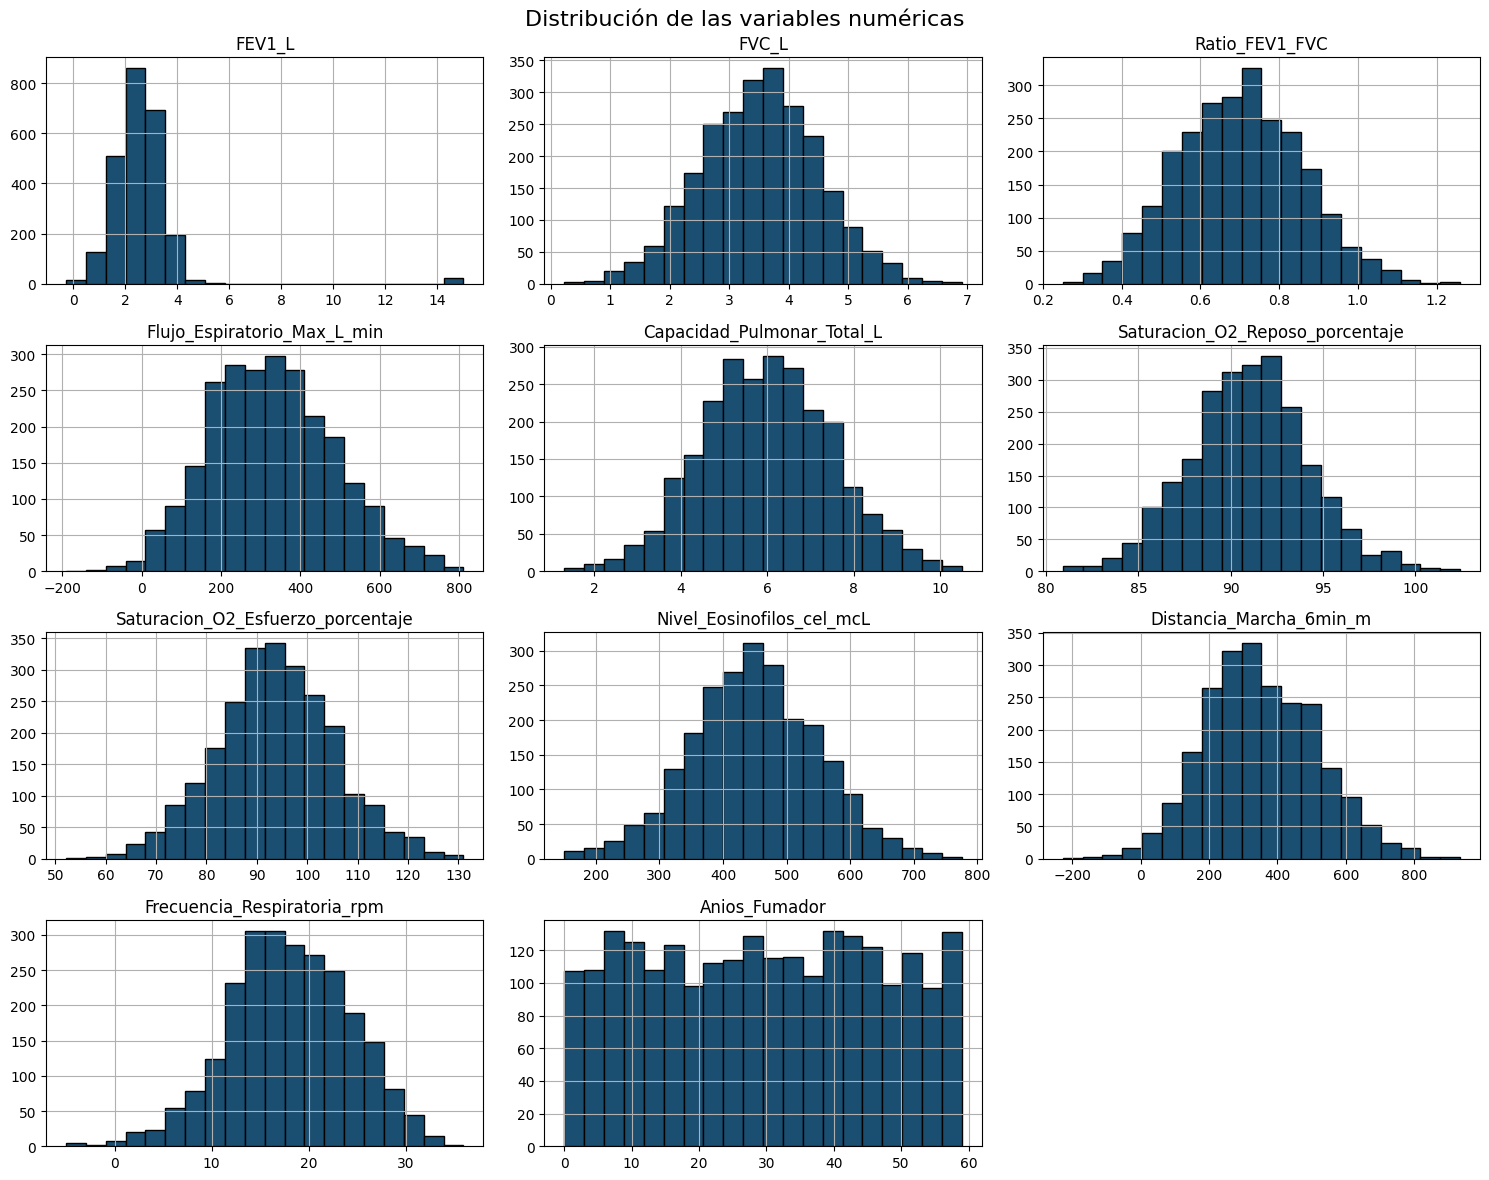

In [ ]:
columnas_numericas = data.select_dtypes(include=['float64', 'int64'])

# Tenemos que excluir la última columna ya que puede ser ifentificada como
# númerica, y solo se quiere variables clínicas
if 'Riesgo_Exacerbacion' in columnas_numericas.columns:
    columnas_numericas = columnas_numericas.drop(columns=['Riesgo_Exacerbacion'])

#Se construye el histograma
columnas_numericas.hist(figsize=(15, 12), bins=20, color='#1B4F72', edgecolor='black')
plt.suptitle('Distribución de las variables numéricas', fontsize=16)
plt.tight_layout()
plt.show()

Durante este primer análisis encontramos varios errores que nos facilitará la realización del "data cleaning" posterior.
1. FEV1_L tiene un valor claramente fuera del límite fisiológico sobre 14 L.
2. Flujo_Espiratorio_Max_L_min tiene valores negativos que no son plausibles y deben ser eliminados.
3. Saturacion_O2_Reposo_porcentaje no puede superar el 100%.
4. Saturacion_O2_Esfuerzo_porcentaje no puede superar el 100%.
5. Distancia_Marcha_6min_m presentan valores negativos imposibles
6. Frecuencia_Respiratoria_rpm presentan valores negativos imposibles.

Aún así debido a la falta de data set solo son preocupantes valores extremos como los 14 L  y el resto serán tomados en cuenta.

Representación de variables categóricas:



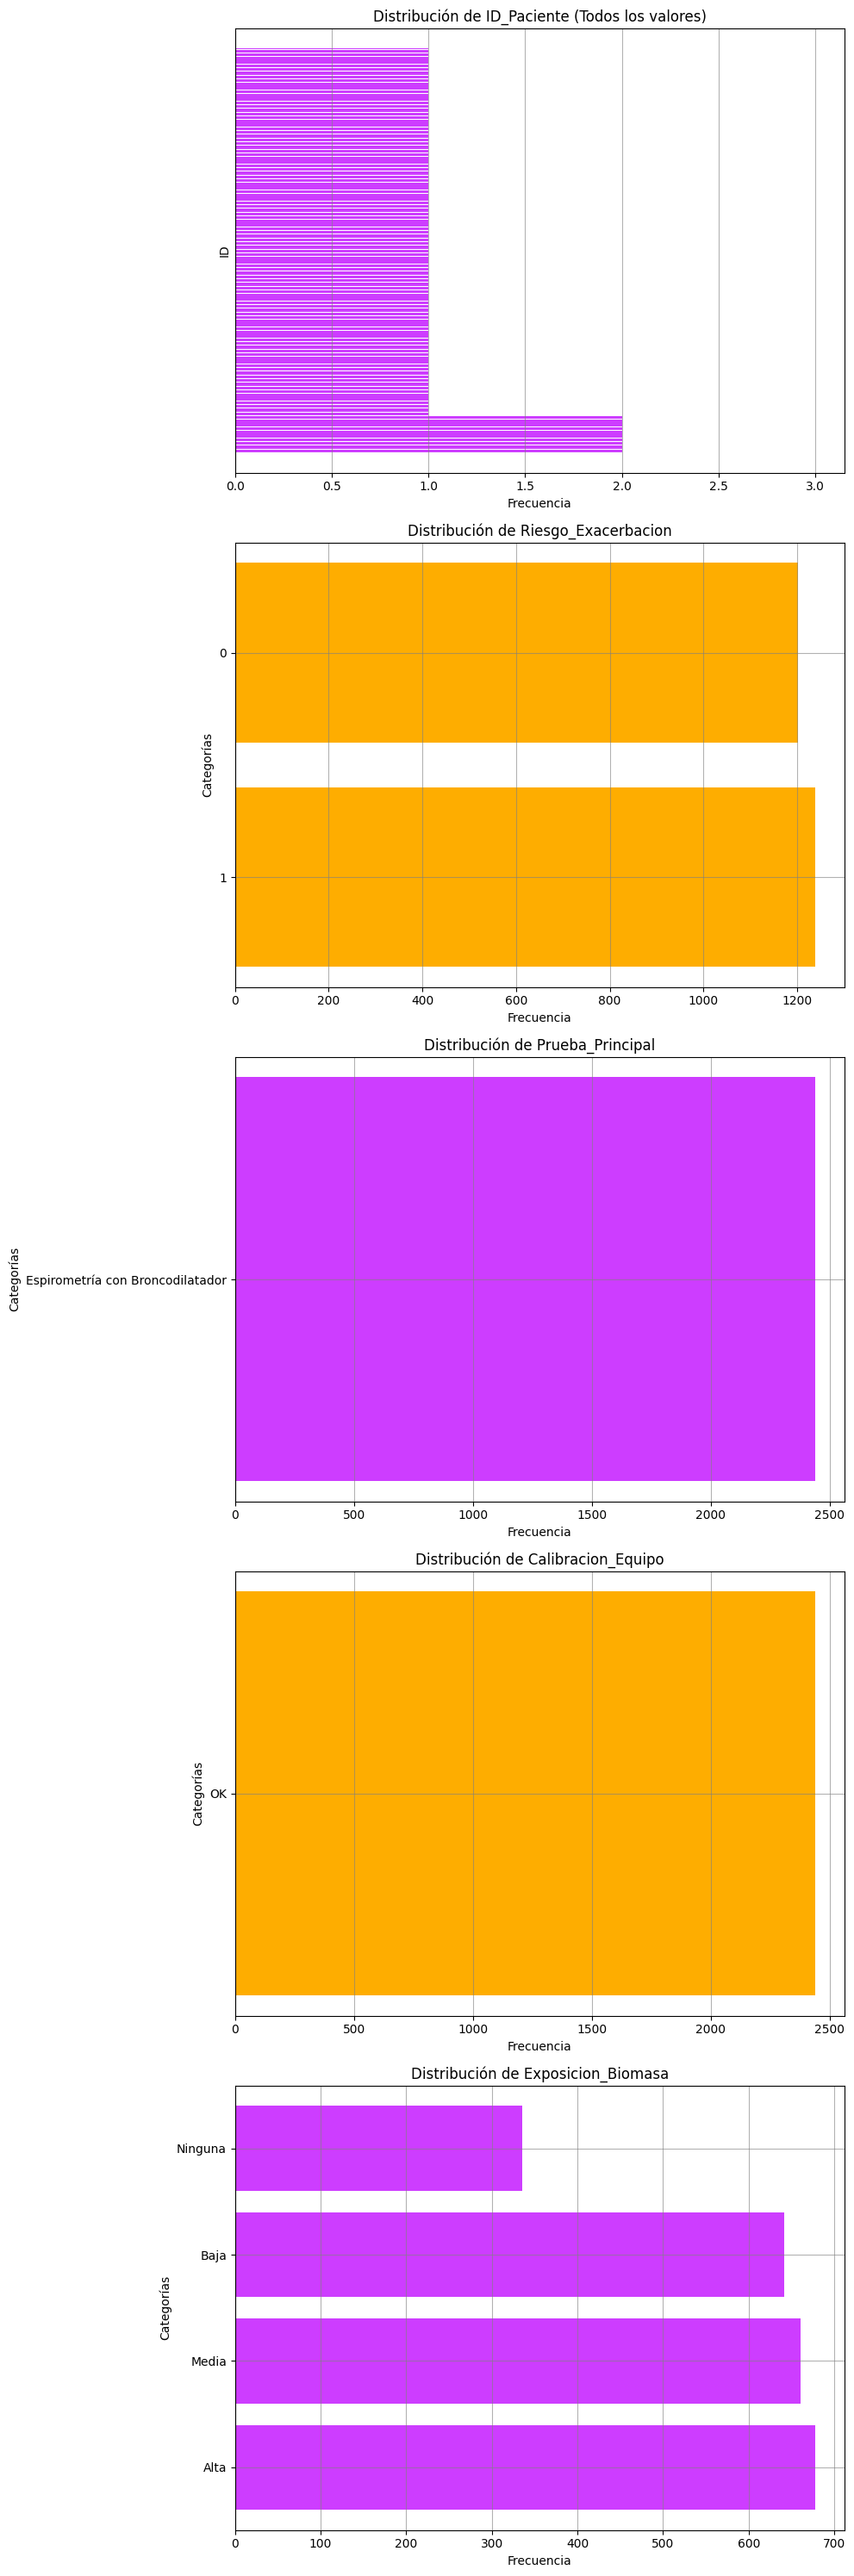

In [ ]:
fig, ejes = plt.subplots(5, 1, figsize=(10, 30))

# Barplot para ID_Paciente
id_counts = data['ID_Paciente'].value_counts()
ejes[0].barh(id_counts.index.astype(str), id_counts.values, color='#CD3DFF')
ejes[0].set_title('Distribución de ID_Paciente (Todos los valores)')
ejes[0].set_xlabel('Frecuencia')
ejes[0].set_ylabel('ID')
ejes[0].set_yticks([]) # Quitamos las etiquetas para no saturar
ejes[0].grid(True, linestyle="-", alpha=0.6, color="gray")

# Barplot para Riesgo_Exacerbacion
riesgo_counts = data['Riesgo_Exacerbacion'].value_counts()
ejes[1].barh(riesgo_counts.index.astype(str), riesgo_counts.values, color='#FEAD00')
ejes[1].set_title('Distribución de Riesgo_Exacerbacion')
ejes[1].set_xlabel('Frecuencia')
ejes[1].set_ylabel('Categorías')
ejes[1].grid(True, linestyle="-", alpha=0.6, color="gray")

# Barplot para Prueba_Principal
prueba_counts = data['Prueba_Principal'].value_counts()
ejes[2].barh(prueba_counts.index.astype(str), prueba_counts.values, color='#CD3DFF')
ejes[2].set_title('Distribución de Prueba_Principal')
ejes[2].set_xlabel('Frecuencia')
ejes[2].set_ylabel('Categorías')
ejes[2].grid(True, linestyle="-", alpha=0.6, color="gray")

# Barplot para Calibracion_Equipo
calib_counts = data['Calibracion_Equipo'].value_counts()
ejes[3].barh(calib_counts.index.astype(str), calib_counts.values, color='#FEAD00')
ejes[3].set_title('Distribución de Calibracion_Equipo')
ejes[3].set_xlabel('Frecuencia')
ejes[3].set_ylabel('Categorías')
ejes[3].grid(True, linestyle="-", alpha=0.6, color="gray")

# Barplot para Exposicion_Biomasa
biomasa_counts = data['Exposicion_Biomasa'].value_counts()
ejes[4].barh(biomasa_counts.index.astype(str), biomasa_counts.values, color='#CD3DFF')
ejes[4].set_title('Distribución de Exposicion_Biomasa')
ejes[4].set_xlabel('Frecuencia')
ejes[4].set_ylabel('Categorías')
ejes[4].grid(True, linestyle="-", alpha=0.6, color="gray")

plt.tight_layout()
plt.show()

La categoría ID no aporta ninguna información por tanto puede ser eliminada. En añadido al graficarla observamos IDs repetidos.

Tanto la  variable de Prueba_Principal como Calibracion_Equipo  solo tienen un valor así que también podría ser eliminada.


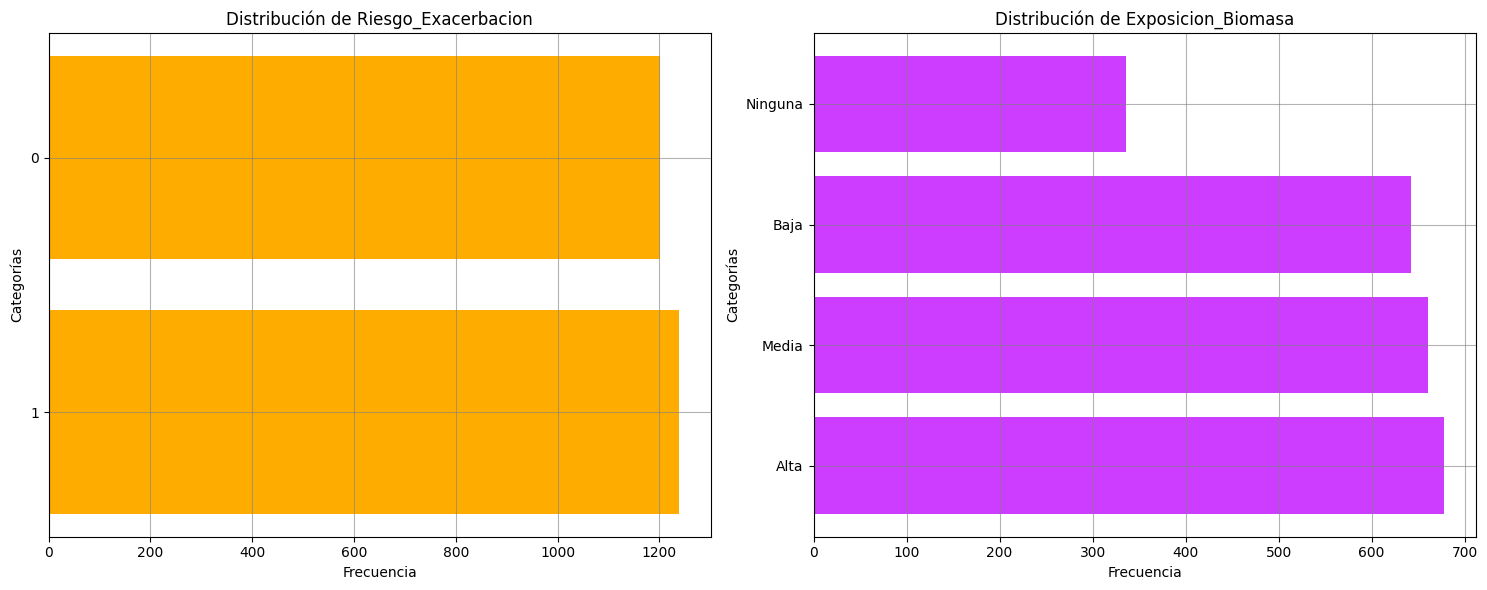

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 6))

# Barplot para Riesgo_Exacerbacion
riesgo_counts = data['Riesgo_Exacerbacion'].value_counts()
ejes[0].barh(riesgo_counts.index.astype(str), riesgo_counts.values, color='#FEAD00')
ejes[0].set_title('Distribución de Riesgo_Exacerbacion')
ejes[0].set_xlabel('Frecuencia')
ejes[0].set_ylabel('Categorías')
ejes[0].grid(True, linestyle="-", alpha=0.6, color="gray")

# Barplot para Exposicion_Biomasa
biomasa_counts = data['Exposicion_Biomasa'].value_counts()
ejes[1].barh(biomasa_counts.index.astype(str), biomasa_counts.values, color='#CD3DFF')
ejes[1].set_title('Distribución de Exposicion_Biomasa')
ejes[1].set_xlabel('Frecuencia')
ejes[1].set_ylabel('Categorías')
ejes[1].grid(True, linestyle="-", alpha=0.6, color="gray")

plt.tight_layout()
plt.show()

# Limpieza de información (data cleaning):
A partir de las conclusiones tomadas en el anterior apartado comenzamos con la limpieza de los datos. En primer lugar se eliminarán las observaciones repetidas que no aportan ninguna información y puede sesgar el análisis y el entrenamiento de los modelos. Y luego se aplicarán los cambios anteriormente mencionados.

In [ ]:
#Eliminación de duplicados
print(data.duplicated().sum())

data = data.drop_duplicates()

#Eliminación de columnas constantes: Prueba_Principal y Calibracion_Equipo
data = data.loc[:, data.nunique() > 1]

#Eliminación columna ID
data = data.drop(columns=["ID_Paciente"])

#Eliminación fila FEV1_L [14L]
data = data[data["FEV1_L"] < 11].copy()

#Se verifica la eliminación de columnas y fila
data.head()



200


,FEV1_L,FVC_L,Ratio_FEV1_FVC,Flujo_Espiratorio_Max_L_min,Capacidad_Pulmonar_Total_L,Saturacion_O2_Reposo_porcentaje,Saturacion_O2_Esfuerzo_porcentaje,Nivel_Eosinofilos_cel_mcL,Distancia_Marcha_6min_m,Frecuencia_Respiratoria_rpm,Anios_Fumador,Exposicion_Biomasa,Riesgo_Exacerbacion
0,1.62,4.25,0.81,491.28,3.92,94.17,107.16,454.82,619.72,22.79,54.0,Media,1
1,3.03,2.89,0.32,179.17,7.74,97.12,68.20,306.63,143.33,18.11,5.0,Alta,0
2,2.59,4.28,0.62,325.11,6.13,90.58,85.20,412.00,270.96,18.93,10.0,Baja,0
3,2.96,2.99,0.54,164.22,8.35,92.91,71.34,292.74,44.52,17.01,16.0,Alta,1
4,2.50,3.57,0.62,760.80,7.36,83.50,72.62,312.11,368.08,30.85,26.0,Alta,1


Sustitución de valores categóricos a numéricos.

La conversión de valores categóricos a númericos es un paso crucial dentro de la preparación de los datos y, sobretodo, dentro de las tareas de inegniería de datos. En muchos casos, en los sitemas de análsis y algoritmos predictivos se requiere de entradas númericas en lugar de categóricas. Este tipo de transformación forma parte de los cambios de formato que permiten adaptar el datasheet a las necesidades del procesamiento posterior.
Sin embargo, en el desarrollo del proyecto, se necesitaba incluir este pase dentro del apartado de limpieza de datos, ya que se encuentra estrechamente relacionado con la depuración y homogeneización del conjunto de datos.

In [ ]:
data = data.copy()
data['Exposicion_Biomasa'] = data['Exposicion_Biomasa'].map({
    'Ninguna': 0,
    'Baja': 1,
    'Media': 2,
    'Alta': 3
})

data.head()

,FEV1_L,FVC_L,Ratio_FEV1_FVC,Flujo_Espiratorio_Max_L_min,Capacidad_Pulmonar_Total_L,Saturacion_O2_Reposo_porcentaje,Saturacion_O2_Esfuerzo_porcentaje,Nivel_Eosinofilos_cel_mcL,Distancia_Marcha_6min_m,Frecuencia_Respiratoria_rpm,Anios_Fumador,Exposicion_Biomasa,Riesgo_Exacerbacion
0,1.62,4.25,0.81,491.28,3.92,94.17,107.16,454.82,619.72,22.79,54.0,2.0,1
1,3.03,2.89,0.32,179.17,7.74,97.12,68.20,306.63,143.33,18.11,5.0,3.0,0
2,2.59,4.28,0.62,325.11,6.13,90.58,85.20,412.00,270.96,18.93,10.0,1.0,0
3,2.96,2.99,0.54,164.22,8.35,92.91,71.34,292.74,44.52,17.01,16.0,3.0,1
4,2.50,3.57,0.62,760.80,7.36,83.50,72.62,312.11,368.08,30.85,26.0,3.0,1


In [ ]:
data['Exposicion_Biomasa'].value_counts(dropna=False) #se observa la distribución real de la columna

,count
Exposicion_Biomasa,
3.0,620
2.0,603
1.0,585
0.0,302
NaN,111


Se realiza por lo tanto, esta tranformación, antes del tratamiento de los valores nulos porque permite trabjar sobre variables ya unificadas.
Así, una vez se han convertido las varibales categóricas a formato númerico, el tratamiento de los valores nulos puede realizarse de forma más consciente sobre el dataset.

GESTIÓN DE VALORES NULOS

Se plantea:
- eliminar filas con nulos
- rellenar con media
- rellenar con moda

In [ ]:
data.isnull().sum()

,0
FEV1_L,0
FVC_L,0
Ratio_FEV1_FVC,0
Flujo_Espiratorio_Max_L_min,0
Capacidad_Pulmonar_Total_L,0
Saturacion_O2_Reposo_porcentaje,0
Saturacion_O2_Esfuerzo_porcentaje,0
Nivel_Eosinofilos_cel_mcL,110
Distancia_Marcha_6min_m,110
Frecuencia_Respiratoria_rpm,0


In [ ]:
#Se separan las columnas númericas y categórica
columnas_numericas_con_nulos = [
    'Nivel_Eosinofilos_cel_mcL',
    'Distancia_Marcha_6min_m',
    'Anios_Fumador'
]
columnas_categoricas_con_nulos = ['Exposicion_Biomasa']

Eliminación de nulos

In [ ]:
data_sin_nulos = data.dropna(subset=columnas_numericas_con_nulos + columnas_categoricas_con_nulos)

print("original:", data.shape)
print("sin nulos:", data_sin_nulos.shape)
data_sin_nulos[columnas_numericas_con_nulos + columnas_categoricas_con_nulos].isnull().sum() #se comrpueba justamente las columnas donde se habían detectado nulos

original: (2221, 13)
sin nulos: (1807, 13)


,0
Nivel_Eosinofilos_cel_mcL,0
Distancia_Marcha_6min_m,0
Anios_Fumador,0
Exposicion_Biomasa,0


Sustitución de nulos por media en variables numéricas

En lugar de eliminar observaciones, se sustituyen los valores nulos de las variables numéricas por la media de cada columna. Así, se pueden conservar todos los registros.


In [ ]:
data_media = data.copy()

for col in columnas_numericas_con_nulos:
   data_media[col] = data_media[col].fillna(data[col].mean())

 #Comprobamos que no hay valores nulos en las columnas numéricas tratadas
data_media[columnas_numericas_con_nulos].isnull().sum()

,0
Nivel_Eosinofilos_cel_mcL,0
Distancia_Marcha_6min_m,0
Anios_Fumador,0


Sustitución de nulos por moda en variables numéricas

Se prueba la sustitución de nulos mediante moda, es decir, utilizando el valor más frecuente de cada variable

In [ ]:
data_moda = data.copy()

for col in columnas_numericas_con_nulos:
    data_moda[col] = data_moda[col].fillna(data[col].mode()[0])

# Comprobamos que no hay valores nulos en las columnas numéricas tratadas
data_moda[columnas_numericas_con_nulos].isnull().sum()

,0
Nivel_Eosinofilos_cel_mcL,0
Distancia_Marcha_6min_m,0
Anios_Fumador,0


Valores que se han empleado para media y moda

In [ ]:
for col in columnas_numericas_con_nulos:
    print(col)
    print("Media:", data[col].mean())
    print("Moda:", data[col].mode()[0])
    print()

Nivel_Eosinofilos_cel_mcL
Media: 448.9493036475604
Moda: 310.38

Distancia_Marcha_6min_m
Media: 351.67027475130266
Moda: 64.58

Anios_Fumador
Media: 29.681042654028435
Moda: 58.0



Al comparar la sustitucion de valores nulos mediante media y moda en las variables númericas, se decide emplear la media. Esto se debe a que las variables númericas aportadas en el dataset corresponden con magnitudes continuas clínicas y su comportamiento lo va a describir mejor la media.
Por ejemplo en la varibale Distancia_Marcha_6min_m, la media obtenida fue aproximadamente 351.67 m, mientras que la moda fue 64.58 m. El valor de la moda es muy bajo en comparación con el comportamiento general de la variable y por lo tanto, no va a representar adecuadamente la distribución del conjunto de datos.

Sustitución de nulos por moda en variable categórica

Aunque Exposicion_Biomasa ya se haya codificado a variable numérica, sigue siendo una variable categórica. Por lo tanto, no se debe sustituir sus valores nulos por la media, ya que podría obtenerse un valor que no corresponde a ninguna categoría real.

In [ ]:
print("Media de Exposicion_Biomasa:", data['Exposicion_Biomasa'].mean())
print("Moda de Exposicion_Biomasa:", data['Exposicion_Biomasa'].mode()[0])

Media de Exposicion_Biomasa: 1.7303317535545024
Moda de Exposicion_Biomasa: 3.0


Como se observa el 1.73 no representa una categoria real.

Categorías:
(Ninguna = 0,
Baja = 1,
Media = 2,
Alta = 3)

Por ello, se emplea la moda

In [ ]:
data_categoria_moda = data.copy()

for col in columnas_categoricas_con_nulos:
    data_categoria_moda[col] = data_categoria_moda[col].fillna(data[col].mode()[0])

# Comprobamos que no hay valores nulos en la variable categórica tratada
data_categoria_moda[columnas_categoricas_con_nulos].isnull().sum()

,0
Exposicion_Biomasa,0


Dataset con Media y Moda

Media para numéricas y moda para variables categóricas

In [ ]:
data_media_moda = data.copy()

print("Nulos iniciales en data_media_moda:")
print(data_media_moda.isnull().sum())

# Variables numéricas por la media
for col in columnas_numericas_con_nulos:
    data_media_moda[col] = data_media_moda[col].fillna(data[col].mean())

# Comprobación de nulos en las variables numéricas
columnas_media = data_media_moda[columnas_numericas_con_nulos]
print("Nulos en variables numéricas:")
print(columnas_media.isnull().sum())

# Variables categóricas por la moda
for col in columnas_categoricas_con_nulos:
    data_media_moda[col] = data_media_moda[col].fillna(data[col].mode()[0])

# Comprobación de nulos en las variables categóricas
columnas_moda = data_media_moda[columnas_categoricas_con_nulos]
print("Nulos en variables categóricas:")
print(columnas_moda.isnull().sum())

print("Nulos finales en data_media_moda:")
print(data_media_moda.isnull().sum())


Nulos iniciales en data_media_moda:
FEV1_L                                 0
FVC_L                                  0
Ratio_FEV1_FVC                         0
Flujo_Espiratorio_Max_L_min            0
Capacidad_Pulmonar_Total_L             0
Saturacion_O2_Reposo_porcentaje        0
Saturacion_O2_Esfuerzo_porcentaje      0
Nivel_Eosinofilos_cel_mcL            110
Distancia_Marcha_6min_m              110
Frecuencia_Respiratoria_rpm            0
Anios_Fumador                        111
Exposicion_Biomasa                   111
Riesgo_Exacerbacion                    0
dtype: int64
Nulos en variables numéricas:
Nivel_Eosinofilos_cel_mcL    0
Distancia_Marcha_6min_m      0
Anios_Fumador                0
dtype: int64
Nulos en variables categóricas:
Exposicion_Biomasa    0
dtype: int64
Nulos finales en data_media_moda:
FEV1_L                               0
FVC_L                                0
Ratio_FEV1_FVC                       0
Flujo_Espiratorio_Max_L_min          0
Capacidad_Pulmonar_Tota

**Filtrado de valores atípicos (outliers):**


Se debe realizar esta etapa en el procesamiento de datos, ya que estos valores extremos pueden alterar el comportamiento de los alrgoritmos de aprendizaje automático. Al desviarse este valor del patrón general de datos, los outliers pueden generar errores en las métricas, fallos en calculos y aumentar el riesgo de sobreajuste. Por esta razón, es necesario realizar tanto la detección como el tratamiento adecuado para poder garantizar la construcción de modelos fiables y generalizables, que son requisitos para alcanzar un buen rendimiento productivo.

Identificar y analizar outliers: Para detectar los valores atípicos de manera visual, se emplea el diagrama de caja o boxplot. Este gráfico muestra aquellos datos que se alejan fuera del patrón general de datos al representar la distribución de valores en torno a la media y los cuartiles

Para la detección de los outliers se han seleccionado únicamente las variables numéricas, ya que los valores atípicos se identifican a partir de la distribución cuantitativa. Sin embargo, las variables categóricas solo representan clases o etiquetas y no magnitudes continuas, por lo que no resulta adecuado estar analizandolas con diagramas de caja.


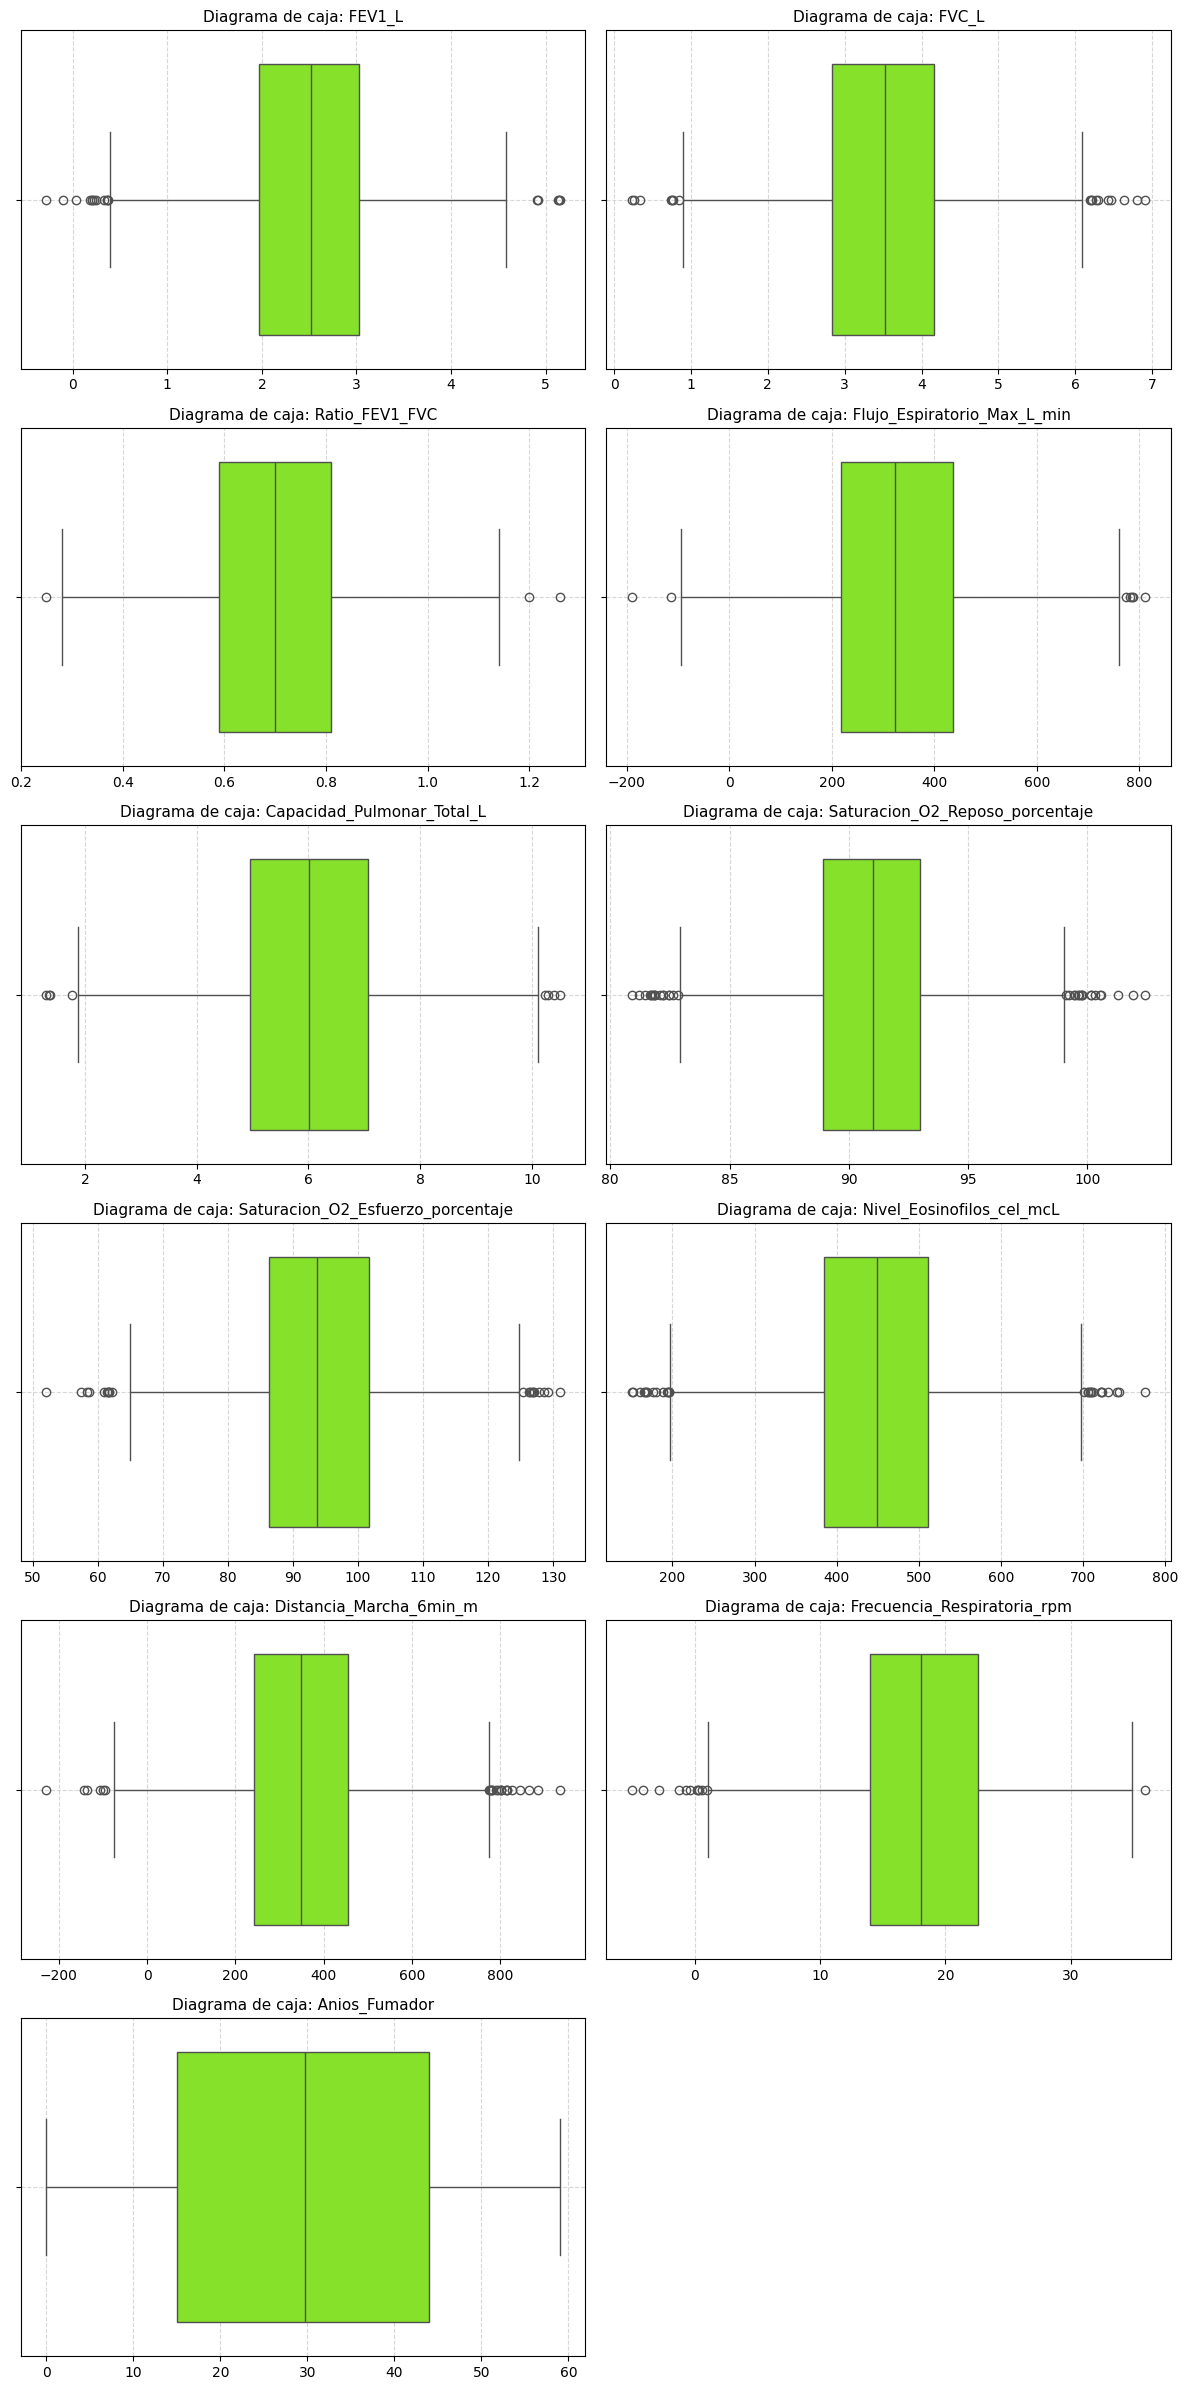

In [ ]:
# se seleccionan columnas numéricas del dataset con nulos sustituidos
columnas_numericas = data_media_moda.select_dtypes(include=['int64', 'float64']).columns

# se quitan variables categóricas
columnas_outliers = columnas_numericas.drop(
    ['Riesgo_Exacerbacion', 'Exposicion_Biomasa'],
    errors='ignore'
)

# se crea figura con subplots
n_columnas = 2
n_filas = math.ceil(len(columnas_outliers) / n_columnas)

fig, ejes = plt.subplots(n_filas, n_columnas, figsize=(12, 4 * n_filas))
ejes = ejes.flatten()

# se dibuja un boxplot por cada variable numérica clínica
for i, col in enumerate(columnas_outliers):
    sns.boxplot(x=data_media_moda[col], ax=ejes[i], color='#85FF0C')
    ejes[i].set_title(f'Diagrama de caja: {col}', fontsize=11)
    ejes[i].set_xlabel('')
    ejes[i].grid(True, linestyle='--', alpha=0.5)


for j in range(i + 1, len(ejes)):
    fig.delaxes(ejes[j])

plt.tight_layout()
plt.show()

Para identificar los outliers se utiliza el rango intercuantílico (IQR), que se calcula a partir de los cuartiles dl diagrama de caja. Se considera dato atípico cuando está por debajo de Q1-1.5×IQR o por encima de Q3+1.5×IQR.
Una vez que se detecten estos valores, se analizan para saber si realmente son errores o si tienen sentido dentro del contexto del datasheet. Según como sean, se pueden eliminar, sustituir o mantener.

Se analiza primero, el datasheet con los nulos sustituidos por media y moda

In [ ]:
# Se seleccionan las variables numéricas del dataset con nulos sustituidos por media/moda
columnas_numericas = data_media_moda.select_dtypes(include=['int64', 'float64']).columns

# Se quitan variables categóricas
columnas_outliers = columnas_numericas.drop(
    ['Riesgo_Exacerbacion', 'Exposicion_Biomasa'],
    errors='ignore'
)

# Creamos una copia para eliminar outliers
data_media_moda_sin_outliers = data_media_moda.copy()

# Eliminamos outliers para cada columna numérica
for col in columnas_outliers:
    Q1 = data_media_moda_sin_outliers[col].quantile(0.25)
    Q3 = data_media_moda_sin_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Máscara para identificar valores no nulos
    mask_no_null = data_media_moda_sin_outliers[col].notnull()

    # Máscara para identificar outliers
    mask_outliers = (
        (data_media_moda_sin_outliers[col] < limite_inferior) |
        (data_media_moda_sin_outliers[col] > limite_superior)
    )

    # Eliminamos solo las filas que son no nulas y outliers
    data_media_moda_sin_outliers = data_media_moda_sin_outliers[~(mask_no_null & mask_outliers)]

print(f'Datos originales data_media_moda: {data_media_moda.shape}')
print(f'Datos data_media_moda sin outliers: {data_media_moda_sin_outliers.shape}')
print('-' * 35)
print('Total de datos eliminados:', data_media_moda.shape[0] - data_media_moda_sin_outliers.shape[0])

Datos originales data_media_moda: (2221, 13)
Datos data_media_moda sin outliers: (2070, 13)
-----------------------------------
Total de datos eliminados: 151


Se han suprimido un total de 151 registros, pasando de un total de 2221 registros iniciales a 2070 registros finales. Esto supone una reducción del 6.80% del total. Esta eliminación de datos se considera adecuada, ya que permite reducir la influencia de los valores extremos que podrían afectar al entrenamiento de modelos y a la interpretación de los resultados. La proporción de datos que se ha eliminado no es muy elevada, por lo que se sigue mantiendo la mayor parte de la información disponible en la datasheet.

En segundo lugar, se realiza la eliminación de outliers sobre datasheet sin nulos.

In [ ]:
# Se seleccionan las variables numéricas del dataset sin nulos
columnas_numericas = data_sin_nulos.select_dtypes(include=['int64', 'float64']).columns

# Se quitan variables categóricas
columnas_outliers = columnas_numericas.drop(
    ['Riesgo_Exacerbacion', 'Exposicion_Biomasa'],
    errors='ignore'
)

# Creamos una copia para eliminar outliers
data_sin_nulos_sin_outliers = data_sin_nulos.copy()

# Eliminamos outliers para cada columna numérica
for col in columnas_outliers:
    Q1 = data_sin_nulos_sin_outliers[col].quantile(0.25)
    Q3 = data_sin_nulos_sin_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Máscara para identificar valores no nulos
    mask_no_null = data_sin_nulos_sin_outliers[col].notnull()

    # Máscara para identificar outliers
    mask_outliers = (
        (data_sin_nulos_sin_outliers[col] < limite_inferior) |
        (data_sin_nulos_sin_outliers[col] > limite_superior)
    )

    # Eliminamos solo las filas que son no nulas y outliers
    data_sin_nulos_sin_outliers = data_sin_nulos_sin_outliers[~(mask_no_null & mask_outliers)]

print(f'Datos originales data_sin_nulos: {data_sin_nulos.shape}')
print(f'Datos data_sin_nulos sin outliers: {data_sin_nulos_sin_outliers.shape}')
print('-' * 35)
print('Total de datos eliminados:', data_sin_nulos.shape[0] - data_sin_nulos_sin_outliers.shape[0])

Datos originales data_sin_nulos: (1807, 13)
Datos data_sin_nulos sin outliers: (1707, 13)
-----------------------------------
Total de datos eliminados: 100


Se han suprimido un total de 100 registros del dataframe "data_sin_nulos", pasando de un total de 1807 registros iniciales a 1707 registros finales. Esto supone una reducción del 5.6% del total. Esta eliminación de datos se considera adecuada, ya que permite reducir la influencia de los valores extremos que podrían afectar al entrenamiento de modelos y a la interpretación de los resultados. La proporción de datos que se ha eliminado no es muy elevada, por lo que se sigue mantiendo la mayor parte de la información disponible en la datasheet.

In [ ]:
print("DATA SIN NULOS")
display(data_sin_nulos.head())

print("DATA MEDIA/MODA")
display(data_media_moda.head())

print("DATA SIN NULOS Y SIN OUTLIERS")
display(data_sin_nulos_sin_outliers.head())

print("DATA MEDIA/MODA Y SIN OUTLIERS")
display(data_media_moda_sin_outliers.head())

DATA SIN NULOS


,FEV1_L,FVC_L,Ratio_FEV1_FVC,Flujo_Espiratorio_Max_L_min,Capacidad_Pulmonar_Total_L,Saturacion_O2_Reposo_porcentaje,Saturacion_O2_Esfuerzo_porcentaje,Nivel_Eosinofilos_cel_mcL,Distancia_Marcha_6min_m,Frecuencia_Respiratoria_rpm,Anios_Fumador,Exposicion_Biomasa,Riesgo_Exacerbacion
0,1.62,4.25,0.81,491.28,3.92,94.17,107.16,454.82,619.72,22.79,54.0,2.0,1
1,3.03,2.89,0.32,179.17,7.74,97.12,68.20,306.63,143.33,18.11,5.0,3.0,0
2,2.59,4.28,0.62,325.11,6.13,90.58,85.20,412.00,270.96,18.93,10.0,1.0,0
3,2.96,2.99,0.54,164.22,8.35,92.91,71.34,292.74,44.52,17.01,16.0,3.0,1
4,2.50,3.57,0.62,760.80,7.36,83.50,72.62,312.11,368.08,30.85,26.0,3.0,1


DATA MEDIA/MODA


,FEV1_L,FVC_L,Ratio_FEV1_FVC,Flujo_Espiratorio_Max_L_min,Capacidad_Pulmonar_Total_L,Saturacion_O2_Reposo_porcentaje,Saturacion_O2_Esfuerzo_porcentaje,Nivel_Eosinofilos_cel_mcL,Distancia_Marcha_6min_m,Frecuencia_Respiratoria_rpm,Anios_Fumador,Exposicion_Biomasa,Riesgo_Exacerbacion
0,1.62,4.25,0.81,491.28,3.92,94.17,107.16,454.82,619.72,22.79,54.0,2.0,1
1,3.03,2.89,0.32,179.17,7.74,97.12,68.20,306.63,143.33,18.11,5.0,3.0,0
2,2.59,4.28,0.62,325.11,6.13,90.58,85.20,412.00,270.96,18.93,10.0,1.0,0
3,2.96,2.99,0.54,164.22,8.35,92.91,71.34,292.74,44.52,17.01,16.0,3.0,1
4,2.50,3.57,0.62,760.80,7.36,83.50,72.62,312.11,368.08,30.85,26.0,3.0,1


DATA SIN NULOS Y SIN OUTLIERS


,FEV1_L,FVC_L,Ratio_FEV1_FVC,Flujo_Espiratorio_Max_L_min,Capacidad_Pulmonar_Total_L,Saturacion_O2_Reposo_porcentaje,Saturacion_O2_Esfuerzo_porcentaje,Nivel_Eosinofilos_cel_mcL,Distancia_Marcha_6min_m,Frecuencia_Respiratoria_rpm,Anios_Fumador,Exposicion_Biomasa,Riesgo_Exacerbacion
0,1.62,4.25,0.81,491.28,3.92,94.17,107.16,454.82,619.72,22.79,54.0,2.0,1
1,3.03,2.89,0.32,179.17,7.74,97.12,68.20,306.63,143.33,18.11,5.0,3.0,0
2,2.59,4.28,0.62,325.11,6.13,90.58,85.20,412.00,270.96,18.93,10.0,1.0,0
3,2.96,2.99,0.54,164.22,8.35,92.91,71.34,292.74,44.52,17.01,16.0,3.0,1
4,2.50,3.57,0.62,760.80,7.36,83.50,72.62,312.11,368.08,30.85,26.0,3.0,1


DATA MEDIA/MODA Y SIN OUTLIERS


,FEV1_L,FVC_L,Ratio_FEV1_FVC,Flujo_Espiratorio_Max_L_min,Capacidad_Pulmonar_Total_L,Saturacion_O2_Reposo_porcentaje,Saturacion_O2_Esfuerzo_porcentaje,Nivel_Eosinofilos_cel_mcL,Distancia_Marcha_6min_m,Frecuencia_Respiratoria_rpm,Anios_Fumador,Exposicion_Biomasa,Riesgo_Exacerbacion
0,1.62,4.25,0.81,491.28,3.92,94.17,107.16,454.82,619.72,22.79,54.0,2.0,1
1,3.03,2.89,0.32,179.17,7.74,97.12,68.20,306.63,143.33,18.11,5.0,3.0,0
2,2.59,4.28,0.62,325.11,6.13,90.58,85.20,412.00,270.96,18.93,10.0,1.0,0
3,2.96,2.99,0.54,164.22,8.35,92.91,71.34,292.74,44.52,17.01,16.0,3.0,1
4,2.50,3.57,0.62,760.80,7.36,83.50,72.62,312.11,368.08,30.85,26.0,3.0,1


**Reducción Dimensionalidad**

Un número elevado de variables puede complicar la interpretación del dataset y afectar al rendimiento de algunos modelos. Por ello, se pueden emplear métodos de reducción de dimensionalidad, que buscan simplificar los datos conservando la información más relevante.

Una opción sencilla consiste en analizar la matriz de correlación para identificar variables muy relacionadas entre sí. Cuando dos variables presentan una correlación elevada, una de ellas puede considerarse redundante y eliminarse. Sin embargo, este método depende del criterio elegido y no siempre permite detectar relaciones complejas.

Otra opción es aplicar PCA, una técnica que genera nuevas variables, llamadas componentes principales, a partir de combinaciones lineales de las variables originales. Estas componentes concentran la mayor parte de la variabilidad de los datos y permiten reducir el número de dimensiones. Aun así, su principal inconveniente es que pierden parte de la interpretación directa, ya que no representan variables clínicas originales, sino combinaciones matemáticas de ellas.

Matriz de Correlación:

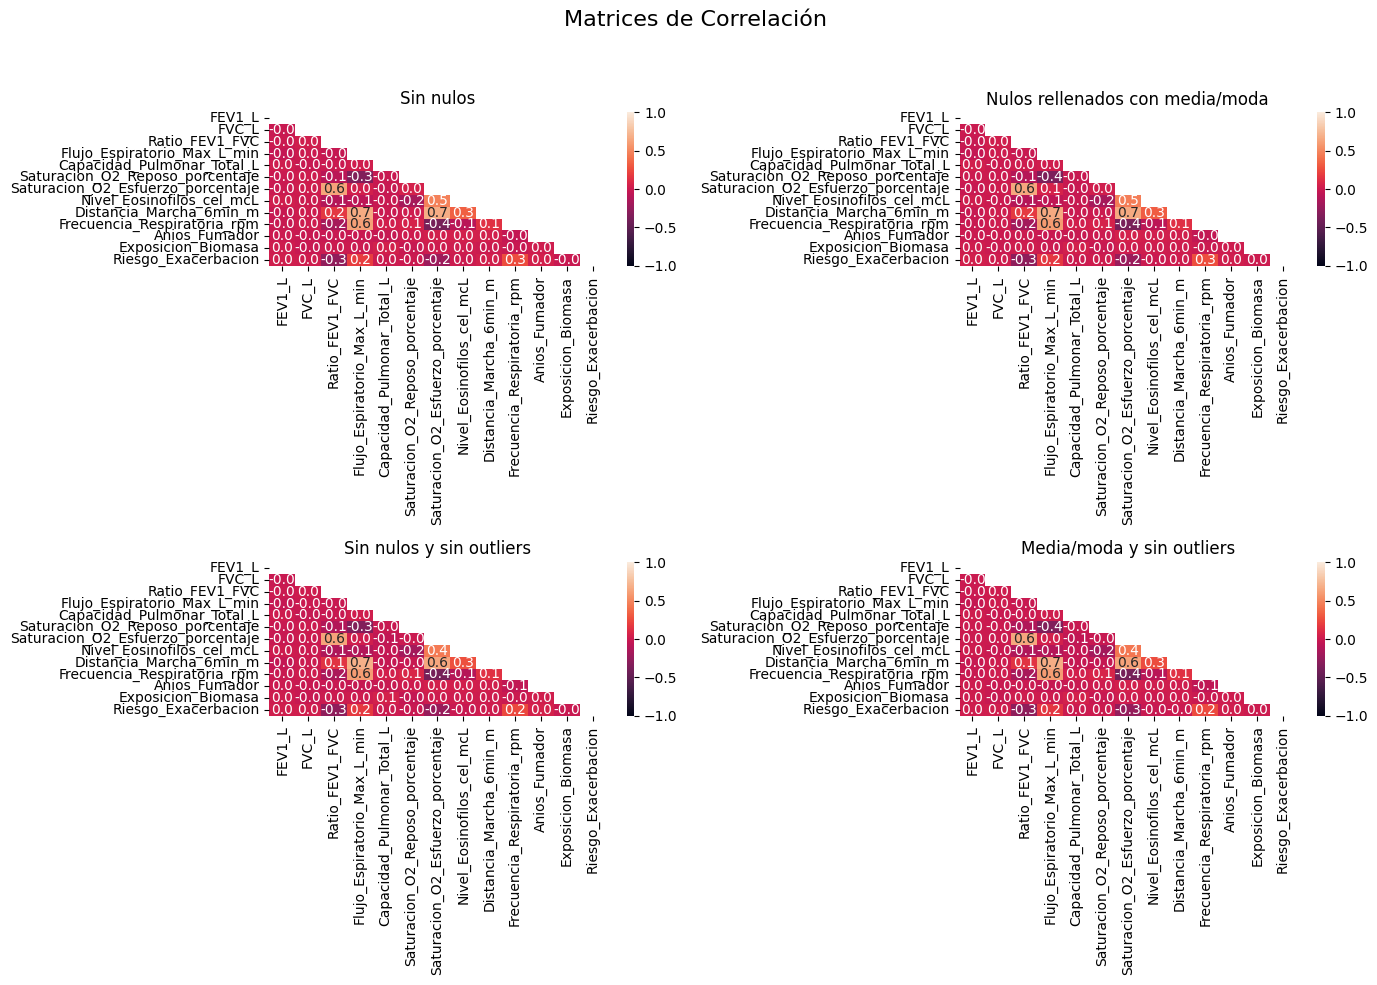

In [ ]:
# se calculan las matrices de correlación
mat_corr_sin_nulos = data_sin_nulos.corr()
mat_corr_media_moda = data_media_moda.corr()
mat_corr_sin_nulos_sin_outliers = data_sin_nulos_sin_outliers.corr()
mat_corr_media_moda_sin_outliers = data_media_moda_sin_outliers.corr()


mascara = np.triu(np.ones(mat_corr_sin_nulos.shape, dtype=bool))
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Matrices de Correlación", fontsize=16)

# Lista de matrices y títulos correspondientes
matrices = [
    (mat_corr_sin_nulos, "Sin nulos"),
    (mat_corr_media_moda, "Nulos rellenados con media/moda"),
    (mat_corr_sin_nulos_sin_outliers, "Sin nulos y sin outliers"),
    (mat_corr_media_moda_sin_outliers, "Media/moda y sin outliers")
]

# se dibujan heatmaps
for ax, (mat, titulo) in zip(axes.flat, matrices):
    sns.heatmap(
        mat,
        annot=True,
        fmt='.1f',
        vmin=-1,
        vmax=1,
        mask=mascara,
        ax=ax
    )
    ax.set_title(titulo)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

En la literatura se ha observado que para eliminar columnas se suele utilizar un criterio de correlación de |0.8| por tanto no se eliminaron columnas mediante matriz de correlación. Es decir, no se observaron correlaciones suficientemente elevadas entre variables predictoras como para considerar que existía una redundancia clara. Aunque alguna relación alcanza valores cercanos a 0.7, se decidió conservar las variables para no perder información clínica relevante.

**Algoritmo PCA**

Para la utilización de este algoritmo es necesario la estandarización de variables y la no presencia de nulos. Por tanto, solo se aplica a los dataframes sin nulos.

Se comienza con "data_sin_nulos"

In [ ]:
data_objetivo_sin_nulos = data_sin_nulos['Riesgo_Exacerbacion']
data_entradas_sin_nulos = data_sin_nulos.drop('Riesgo_Exacerbacion', axis=1)

scaler = StandardScaler()
scaler.fit(data_entradas_sin_nulos)

entradas_estand_sin_nulos = scaler.transform(data_entradas_sin_nulos)

entradas_estand_sin_nulos = pd.DataFrame(data=entradas_estand_sin_nulos,columns=data_entradas_sin_nulos.columns)

In [ ]:
nComponentes = 7
pca_sin_nulos_7 = PCA(n_components=nComponentes)
pca_sin_nulos_7.fit(entradas_estand_sin_nulos)
X_pca_sin_nulos_7 = pca_sin_nulos_7.transform(entradas_estand_sin_nulos)
varianzas_sin_nulos_7 = pca_sin_nulos_7.explained_variance_ratio_

print("Varianzas:", varianzas_sin_nulos_7)
print("Varianza acumulada:", varianzas_sin_nulos_7.cumsum())

Varianzas: [0.1931885  0.16263317 0.09710563 0.09103105 0.08713693 0.08386868
 0.08196442]
Varianza acumulada: [0.1931885  0.35582167 0.4529273  0.54395835 0.63109528 0.71496396
 0.79692838]


In [ ]:
nComponentes = 9
pca_sin_nulos_9 = PCA(n_components=nComponentes)

pca_sin_nulos_9.fit(entradas_estand_sin_nulos)

X_pca_sin_nulos_9 = pca_sin_nulos_9.transform(entradas_estand_sin_nulos)

varianzas_sin_nulos_9 = pca_sin_nulos_9.explained_variance_ratio_

print("Varianzas:", varianzas_sin_nulos_9)
print("Varianza acumulada:", varianzas_sin_nulos_9.cumsum())

Varianzas: [0.1931885  0.16263317 0.09710563 0.09103105 0.08713693 0.08386868
 0.08196442 0.08187454 0.0779383 ]
Varianza acumulada: [0.1931885  0.35582167 0.4529273  0.54395835 0.63109528 0.71496396
 0.79692838 0.87880292 0.95674122]


In [ ]:
nComponentes = 10
pca_sin_nulos_10 = PCA(n_components=nComponentes)
pca_sin_nulos_10.fit(entradas_estand_sin_nulos)
X_pca_sin_nulos_10 = pca_sin_nulos_10.transform(entradas_estand_sin_nulos)
varianzas_sin_nulos_10 = pca_sin_nulos_10.explained_variance_ratio_

print("Varianzas:", varianzas_sin_nulos_10)
print("Varianza acumulada:", varianzas_sin_nulos_10.cumsum())

Varianzas: [0.1931885  0.16263317 0.09710563 0.09103105 0.08713693 0.08386868
 0.08196442 0.08187454 0.0779383  0.04325408]
Varianza acumulada: [0.1931885  0.35582167 0.4529273  0.54395835 0.63109528 0.71496396
 0.79692838 0.87880292 0.95674122 0.9999953 ]


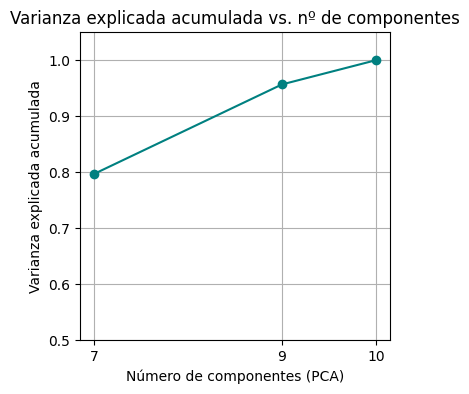

In [ ]:
# Representación de la varianza en función del número de componentes
suma_varianzas = [
    sum(varianzas_sin_nulos_7),
    sum(varianzas_sin_nulos_9),
    sum(varianzas_sin_nulos_10)
]

# Número de componentes correspondientes
componentes = [7, 9, 10]

# Graficar
plt.figure(figsize=(4, 4))
plt.plot(componentes, suma_varianzas, marker='o', linestyle='-', color='teal')
plt.title('Varianza explicada acumulada vs. nº de componentes')
plt.xlabel('Número de componentes (PCA)')
plt.ylabel('Varianza explicada acumulada')
plt.grid(True)
plt.ylim(0.5, 1.05)
plt.xticks(componentes)
plt.show()

En el dataset sin nulos, 7 componentes conservan aproximadamente el 79,69% de la varianza, mientras que 9 componentes alcanzan el 95,67%. Aunque con 10 componentes se conserva prácticamente el 100%, la mejora respecto a 9 componentes no compensa demasiado, ya que apenas se gana información adicional. Por ello, se seleccionan 9 componentes como opción más equilibrada para aplicar PCA.

Se continua con "data_media_moda":

PCA con 7 componentes
Varianzas: [0.19377122 0.15995922 0.09510358 0.09084514 0.08783748 0.08347334
 0.08244579]
Varianza acumulada: [0.19377122 0.35373044 0.44883402 0.53967916 0.62751665 0.71098999
 0.79343578]

PCA con 9 componentes
Varianzas: [0.19377122 0.15995922 0.09510358 0.09084514 0.08783748 0.08347334
 0.08244579 0.08059999 0.07897821]
Varianza acumulada: [0.19377122 0.35373044 0.44883402 0.53967916 0.62751665 0.71098999
 0.79343578 0.87403577 0.95301398]

PCA con 10 componentes
Varianzas: [0.19377122 0.15995922 0.09510358 0.09084514 0.08783748 0.08347334
 0.08244579 0.08059999 0.07897821 0.04440493]
Varianza acumulada: [0.19377122 0.35373044 0.44883402 0.53967916 0.62751665 0.71098999
 0.79343578 0.87403577 0.95301398 0.9974189 ]


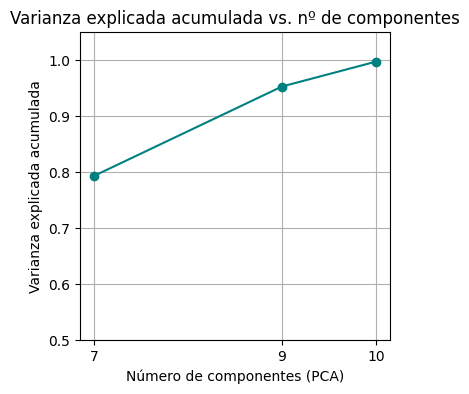

In [ ]:
data_objetivo_media_moda = data_media_moda['Riesgo_Exacerbacion']
data_entradas_media_moda = data_media_moda.drop('Riesgo_Exacerbacion', axis=1)

scaler = StandardScaler()
scaler.fit(data_entradas_media_moda)

entradas_estand_media_moda = scaler.transform(data_entradas_media_moda)

entradas_estand_media_moda = pd.DataFrame(
    data=entradas_estand_media_moda,
    columns=data_entradas_media_moda.columns
)



nComponentes = 7
pca_media_moda_7 = PCA(n_components=nComponentes)
pca_media_moda_7.fit(entradas_estand_media_moda)

X_pca_media_moda_7 = pca_media_moda_7.transform(entradas_estand_media_moda)
varianzas_media_moda_7 = pca_media_moda_7.explained_variance_ratio_

print("PCA con 7 componentes")
print("Varianzas:", varianzas_media_moda_7)
print("Varianza acumulada:", varianzas_media_moda_7.cumsum())




nComponentes = 9
pca_media_moda_9 = PCA(n_components=nComponentes)
pca_media_moda_9.fit(entradas_estand_media_moda)

X_pca_media_moda_9 = pca_media_moda_9.transform(entradas_estand_media_moda)
varianzas_media_moda_9 = pca_media_moda_9.explained_variance_ratio_

print("\nPCA con 9 componentes")
print("Varianzas:", varianzas_media_moda_9)
print("Varianza acumulada:", varianzas_media_moda_9.cumsum())




nComponentes = 10
pca_media_moda_10 = PCA(n_components=nComponentes)
pca_media_moda_10.fit(entradas_estand_media_moda)

X_pca_media_moda_10 = pca_media_moda_10.transform(entradas_estand_media_moda)
varianzas_media_moda_10 = pca_media_moda_10.explained_variance_ratio_

print("\nPCA con 10 componentes")
print("Varianzas:", varianzas_media_moda_10)
print("Varianza acumulada:", varianzas_media_moda_10.cumsum())




# Representación de la varianza en función del número de componentes
suma_varianzas = [
    sum(varianzas_media_moda_7),
    sum(varianzas_media_moda_9),
    sum(varianzas_media_moda_10)
]

# Número de componentes correspondientes
componentes = [7, 9, 10]

# Graficar
plt.figure(figsize=(4, 4))
plt.plot(componentes, suma_varianzas, marker='o', linestyle='-', color='teal')
plt.title('Varianza explicada acumulada vs. nº de componentes')
plt.xlabel('Número de componentes (PCA)')
plt.ylabel('Varianza explicada acumulada')
plt.grid(True)
plt.ylim(0.5, 1.05)
plt.xticks(componentes)
plt.show()

En el dataset con nulos sustituidos mediante media/moda, 7 componentes conservan aproximadamente el 79,34% de la varianza, por lo que todavía se perdería una parte importante de la información original. Con 9 componentes se alcanza aproximadamente el 95,30%, lo que permite conservar la mayor parte de la información del dataset. Aunque con 10 componentes se llega prácticamente al 99,74%, la mejora respecto a 9 componentes es pequeña.

Por ello, se seleccionan 9 componentes como la opción más equilibrada, ya que permiten reducir ligeramente la dimensionalidad manteniendo más del 95% de la varianza original.

En tercer lugar, "data_sin_nulos_sin_outliers":

PCA con 7 componentes
Varianzas: [0.18909083 0.16302015 0.09860588 0.09198565 0.08697435 0.08289057
 0.08214982]
Varianza acumulada: [0.18909083 0.35211098 0.45071686 0.54270252 0.62967686 0.71256743
 0.79471725]

PCA con 9 componentes
Varianzas: [0.18909083 0.16302015 0.09860588 0.09198565 0.08697435 0.08289057
 0.08214982 0.08139694 0.07756473]
Varianza acumulada: [0.18909083 0.35211098 0.45071686 0.54270252 0.62967686 0.71256743
 0.79471725 0.87611418 0.95367892]

PCA con 10 componentes
Varianzas: [0.18909083 0.16302015 0.09860588 0.09198565 0.08697435 0.08289057
 0.08214982 0.08139694 0.07756473 0.04631585]
Varianza acumulada: [0.18909083 0.35211098 0.45071686 0.54270252 0.62967686 0.71256743
 0.79471725 0.87611418 0.95367892 0.99999476]


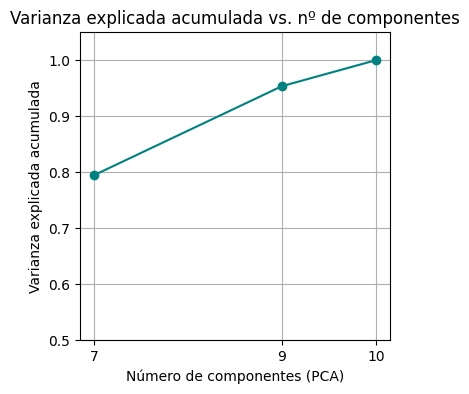

In [ ]:
data_objetivo_sin_nulos_sin_outliers = data_sin_nulos_sin_outliers['Riesgo_Exacerbacion']
data_entradas_sin_nulos_sin_outliers = data_sin_nulos_sin_outliers.drop('Riesgo_Exacerbacion', axis=1)

scaler = StandardScaler()
scaler.fit(data_entradas_sin_nulos_sin_outliers)

entradas_estand_sin_nulos_sin_outliers = scaler.transform(data_entradas_sin_nulos_sin_outliers)

entradas_estand_sin_nulos_sin_outliers = pd.DataFrame(
    data=entradas_estand_sin_nulos_sin_outliers,
    columns=data_entradas_sin_nulos_sin_outliers.columns
)



nComponentes = 7
pca_sin_nulos_sin_outliers_7 = PCA(n_components=nComponentes)
pca_sin_nulos_sin_outliers_7.fit(entradas_estand_sin_nulos_sin_outliers)

X_pca_sin_nulos_sin_outliers_7 = pca_sin_nulos_sin_outliers_7.transform(
    entradas_estand_sin_nulos_sin_outliers
)

varianzas_sin_nulos_sin_outliers_7 = pca_sin_nulos_sin_outliers_7.explained_variance_ratio_

print("PCA con 7 componentes")
print("Varianzas:", varianzas_sin_nulos_sin_outliers_7)
print("Varianza acumulada:", varianzas_sin_nulos_sin_outliers_7.cumsum())




nComponentes = 9
pca_sin_nulos_sin_outliers_9 = PCA(n_components=nComponentes)
pca_sin_nulos_sin_outliers_9.fit(entradas_estand_sin_nulos_sin_outliers)

X_pca_sin_nulos_sin_outliers_9 = pca_sin_nulos_sin_outliers_9.transform(
    entradas_estand_sin_nulos_sin_outliers
)

varianzas_sin_nulos_sin_outliers_9 = pca_sin_nulos_sin_outliers_9.explained_variance_ratio_

print("\nPCA con 9 componentes")
print("Varianzas:", varianzas_sin_nulos_sin_outliers_9)
print("Varianza acumulada:", varianzas_sin_nulos_sin_outliers_9.cumsum())




nComponentes = 10
pca_sin_nulos_sin_outliers_10 = PCA(n_components=nComponentes)
pca_sin_nulos_sin_outliers_10.fit(entradas_estand_sin_nulos_sin_outliers)

X_pca_sin_nulos_sin_outliers_10 = pca_sin_nulos_sin_outliers_10.transform(
    entradas_estand_sin_nulos_sin_outliers
)

varianzas_sin_nulos_sin_outliers_10 = pca_sin_nulos_sin_outliers_10.explained_variance_ratio_

print("\nPCA con 10 componentes")
print("Varianzas:", varianzas_sin_nulos_sin_outliers_10)
print("Varianza acumulada:", varianzas_sin_nulos_sin_outliers_10.cumsum())




# Representación de la varianza en función del número de componentes
suma_varianzas = [
    sum(varianzas_sin_nulos_sin_outliers_7),
    sum(varianzas_sin_nulos_sin_outliers_9),
    sum(varianzas_sin_nulos_sin_outliers_10)
]

# Número de componentes correspondientes
componentes = [7, 9, 10]

# Graficar
plt.figure(figsize=(4, 4))
plt.plot(componentes, suma_varianzas, marker='o', linestyle='-', color='teal')
plt.title('Varianza explicada acumulada vs. nº de componentes')
plt.xlabel('Número de componentes (PCA)')
plt.ylabel('Varianza explicada acumulada')
plt.grid(True)
plt.ylim(0.5, 1.05)
plt.xticks(componentes)
plt.show()

En el dataset sin nulos y sin outliers, 7 componentes conservan aproximadamente el 79,47% de la varianza, por lo que todavía se perdería una parte importante de la información original. Con 9 componentes se alcanza aproximadamente el 95,37%, lo que permite mantener la mayor parte de la información del dataset.

Aunque con 10 componentes se conserva prácticamente el 100% de la varianza, la mejora respecto a 9 componentes es reducida. Por ello, se seleccionan 9 componentes como la opción más equilibrada, ya que permiten reducir ligeramente la dimensionalidad manteniendo más del 95% de la varianza original. Posteriormente, será necesario comprobar si esta transformación mediante PCA mejora el rendimiento predictivo frente al uso de las variables originales.


Por último "data_media_moda_sin_outliers":

PCA con 7 componentes
Varianzas: [0.18850279 0.16223505 0.0970895  0.09051494 0.08708783 0.08318295
 0.08203512]
Varianza acumulada: [0.18850279 0.35073784 0.44782734 0.53834228 0.62543012 0.70861307
 0.79064819]

PCA con 9 componentes
Varianzas: [0.18850279 0.16223505 0.0970895  0.09051494 0.08708783 0.08318295
 0.08203512 0.08150428 0.07838168]
Varianza acumulada: [0.18850279 0.35073784 0.44782734 0.53834228 0.62543012 0.70861307
 0.79064819 0.87215247 0.95053415]

PCA con 10 componentes
Varianzas: [0.18850279 0.16223505 0.0970895  0.09051494 0.08708783 0.08318295
 0.08203512 0.08150428 0.07838168 0.04676112]
Varianza acumulada: [0.18850279 0.35073784 0.44782734 0.53834228 0.62543012 0.70861307
 0.79064819 0.87215247 0.95053415 0.99729527]


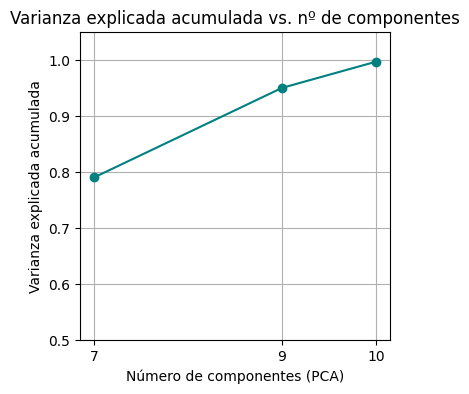

In [ ]:
data_objetivo_media_moda_sin_outliers = data_media_moda_sin_outliers['Riesgo_Exacerbacion']
data_entradas_media_moda_sin_outliers = data_media_moda_sin_outliers.drop('Riesgo_Exacerbacion', axis=1)

scaler = StandardScaler()
scaler.fit(data_entradas_media_moda_sin_outliers)

entradas_estand_media_moda_sin_outliers = scaler.transform(data_entradas_media_moda_sin_outliers)

entradas_estand_media_moda_sin_outliers = pd.DataFrame(
    data=entradas_estand_media_moda_sin_outliers,
    columns=data_entradas_media_moda_sin_outliers.columns
)



nComponentes = 7
pca_media_moda_sin_outliers_7 = PCA(n_components=nComponentes)
pca_media_moda_sin_outliers_7.fit(entradas_estand_media_moda_sin_outliers)

X_pca_media_moda_sin_outliers_7 = pca_media_moda_sin_outliers_7.transform(
    entradas_estand_media_moda_sin_outliers
)

varianzas_media_moda_sin_outliers_7 = pca_media_moda_sin_outliers_7.explained_variance_ratio_

print("PCA con 7 componentes")
print("Varianzas:", varianzas_media_moda_sin_outliers_7)
print("Varianza acumulada:", varianzas_media_moda_sin_outliers_7.cumsum())




nComponentes = 9
pca_media_moda_sin_outliers_9 = PCA(n_components=nComponentes)
pca_media_moda_sin_outliers_9.fit(entradas_estand_media_moda_sin_outliers)

X_pca_media_moda_sin_outliers_9 = pca_media_moda_sin_outliers_9.transform(
    entradas_estand_media_moda_sin_outliers
)

varianzas_media_moda_sin_outliers_9 = pca_media_moda_sin_outliers_9.explained_variance_ratio_

print("\nPCA con 9 componentes")
print("Varianzas:", varianzas_media_moda_sin_outliers_9)
print("Varianza acumulada:", varianzas_media_moda_sin_outliers_9.cumsum())




nComponentes = 10
pca_media_moda_sin_outliers_10 = PCA(n_components=nComponentes)
pca_media_moda_sin_outliers_10.fit(entradas_estand_media_moda_sin_outliers)

X_pca_media_moda_sin_outliers_10 = pca_media_moda_sin_outliers_10.transform(
    entradas_estand_media_moda_sin_outliers
)

varianzas_media_moda_sin_outliers_10 = pca_media_moda_sin_outliers_10.explained_variance_ratio_

print("\nPCA con 10 componentes")
print("Varianzas:", varianzas_media_moda_sin_outliers_10)
print("Varianza acumulada:", varianzas_media_moda_sin_outliers_10.cumsum())




# Representación de la varianza en función del número de componentes
suma_varianzas = [
    sum(varianzas_media_moda_sin_outliers_7),
    sum(varianzas_media_moda_sin_outliers_9),
    sum(varianzas_media_moda_sin_outliers_10)
]

# Número de componentes correspondientes
componentes = [7, 9, 10]

# Graficar
plt.figure(figsize=(4, 4))
plt.plot(componentes, suma_varianzas, marker='o', linestyle='-', color='teal')
plt.title('Varianza explicada acumulada vs. nº de componentes')
plt.xlabel('Número de componentes (PCA)')
plt.ylabel('Varianza explicada acumulada')
plt.grid(True)
plt.ylim(0.5, 1.05)
plt.xticks(componentes)
plt.show()

En el dataset con nulos sustituidos mediante media/moda y sin outliers, 7 componentes conservan aproximadamente el 79,06% de la varianza, por lo que se perdería bastante información. Con 9 componentes se alcanza aproximadamente el 95,05%, manteniendo la mayor parte de la información del dataset.

Aunque con 10 componentes se llega aproximadamente al 99,73%, la mejora respecto a 9 componentes es pequeña. Por ello, se seleccionan 9 componentes como opción más equilibrada, ya que reducen ligeramente la dimensionalidad conservando más del 95% de la varianza original.

## Validación de la mejor estratregia de preparación de datos

Para decidir qué estrategia de preprocesamiento resulta más conveniente para nuestro dataset, se compararán distintas versiones del conjunto de datos generadas mediante diferentes técnicas de limpieza y transformación. Cada una de estas versiones será evaluada con el mismo algoritmo, de forma que sea posible identificar cuál ofrece un mejor rendimiento predictivo y, por tanto, cuál constituye la opción más adecuada para el modelo final.

Para esta comparación se ha seleccionado el algoritmo de Máquinas de Vectores de Soporte (SVM). Este modelo resulta apropiado para este tipo de análisis, ya que puede trabajar correctamente con conjuntos de datos no excesivamente grandes y permite abordar relaciones tanto lineales como no lineales mediante el uso de distintos kernels. Además, al incorporar regularización, ayuda a controlar el sobreajuste, lo que permite obtener una comparación más fiable entre las distintas estrategias de preprocesado aplicadas.

Dataset con eliminación de nulos:

In [ ]:
#separación de columnas objetivo y entrada, separación entre datasets de entrenamiento y validación y estandarización

X_data_sin_nulos = data_sin_nulos.loc[:, data_sin_nulos.columns != 'Riesgo_Exacerbacion'].copy()
Y_data_sin_nulos = data_sin_nulos['Riesgo_Exacerbacion'].copy()

X_data_sin_nulos_train, X_data_sin_nulos_test, Y_data_sin_nulos_train, Y_data_sin_nulos_test = train_test_split( X_data_sin_nulos, Y_data_sin_nulos, random_state=42)

X_data_sin_nulos_train_scaled = scale(X_data_sin_nulos_train)
X_data_sin_nulos_test_scaled = scale(X_data_sin_nulos_test)

In [ ]:
#mejor combinación de parametros  SVM


param_grid = {
    'C': [1, 10, 100, 1000],
    'gamma': [0.1, 0.01, 0.001, 0.0001, 0.00001],
    'kernel': ['rbf', 'sigmoid']}

grid_sin_nulos = GridSearchCV( SVC(),param_grid,refit=True,error_score='raise' )

grid_sin_nulos.fit(X_data_sin_nulos_train_scaled,Y_data_sin_nulos_train)

grid_sin_nulos.best_params_

{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}

In [ ]:
#Creación, entrenamiento y predicción SVM
clf_svm_data_sin_nulos = SVC(random_state=42, C=100, gamma=0.01, kernel='rbf')

clf_svm_data_sin_nulos.fit(X_data_sin_nulos_train_scaled, Y_data_sin_nulos_train)

Y_data_sin_nulos_pred = clf_svm_data_sin_nulos.predict(X_data_sin_nulos_test_scaled)

In [ ]:
#Matriz de confusión y cálculo de exactitud
cm_sin_nulos = confusion_matrix(Y_data_sin_nulos_test, Y_data_sin_nulos_pred)
print("Matriz de confusión:")
print(cm_sin_nulos)

ac_sin_nulos = accuracy_score(Y_data_sin_nulos_test, Y_data_sin_nulos_pred)
print("Exactitud:", ac_sin_nulos)

Matriz de confusión:
[[180  59]
 [ 44 169]]
Exactitud: 0.7721238938053098


Dataset con nulos intercambiados por media y moda:

In [ ]:


# Separar variables de entrada y variable objetivo
X_data_media_moda = data_media_moda.loc[:, data_media_moda.columns != 'Riesgo_Exacerbacion'].copy()
Y_data_media_moda = data_media_moda['Riesgo_Exacerbacion'].copy()


# División en entrenamiento y test
X_data_media_moda_train, X_data_media_moda_test, Y_data_media_moda_train, Y_data_media_moda_test = train_test_split(X_data_media_moda,Y_data_media_moda,random_state=42)


# Escalado de los datos
X_data_media_moda_train_scaled = scale(X_data_media_moda_train)
X_data_media_moda_test_scaled = scale(X_data_media_moda_test)


# Búsqueda de mejores hiperparámetros
param_grid = {
    'C': [1, 10, 100, 1000],
    'gamma': [0.1, 0.01, 0.001, 0.0001, 0.00001],
    'kernel': ['rbf', 'sigmoid']}

grid_media_moda = GridSearchCV(SVC(),param_grid,refit=True,error_score='raise')

grid_media_moda.fit(X_data_media_moda_train_scaled,Y_data_media_moda_train)

print("Mejores parámetros:")
print(grid_media_moda.best_params_)


# Creación del clasificador SVM
# Cambia C, gamma y kernel según lo que te salga arriba en grid_media_moda.best_params_
clf_svm_data_media_moda = SVC(
    random_state=42,
    C=100,
    gamma=0.01,
    kernel='rbf')


# Entrenamiento del clasificador
clf_svm_data_media_moda.fit(X_data_media_moda_train_scaled,Y_data_media_moda_train)


# Predicción sobre los datos de test
Y_data_media_moda_pred = clf_svm_data_media_moda.predict(X_data_media_moda_test_scaled)


# Matriz de confusión
cm_media_moda = confusion_matrix(Y_data_media_moda_test,Y_data_media_moda_pred)

print("Matriz de confusión:")
print(cm_media_moda)


# Cálculo de la exactitud
ac_media_moda = accuracy_score( Y_data_media_moda_test,Y_data_media_moda_pred)

print("Exactitud:", ac_media_moda)

Mejores parámetros:
{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Matriz de confusión:
[[222  48]
 [ 56 230]]
Exactitud: 0.8129496402877698


A continuación se aplica al dataframe sin nulos ni outliers:

In [ ]:
# Separar variables de entrada y variable objetivo
X_data_sin_nulos_sin_outliers = data_sin_nulos_sin_outliers.loc[:, data_sin_nulos_sin_outliers.columns != 'Riesgo_Exacerbacion'].copy()
Y_data_sin_nulos_sin_outliers = data_sin_nulos_sin_outliers['Riesgo_Exacerbacion'].copy()


# División en entrenamiento y test
X_data_sin_nulos_sin_outliers_train, X_data_sin_nulos_sin_outliers_test, Y_data_sin_nulos_sin_outliers_train, Y_data_sin_nulos_sin_outliers_test = train_test_split(X_data_sin_nulos_sin_outliers,Y_data_sin_nulos_sin_outliers,random_state=42)


# Escalado de los datos
X_data_sin_nulos_sin_outliers_train_scaled = scale(X_data_sin_nulos_sin_outliers_train)
X_data_sin_nulos_sin_outliers_test_scaled = scale(X_data_sin_nulos_sin_outliers_test)


# Búsqueda de mejores hiperparámetros
param_grid = {
    'C': [1, 10, 100, 1000],
    'gamma': [0.1, 0.01, 0.001, 0.0001, 0.00001],
    'kernel': ['rbf', 'sigmoid']
}

grid_sin_nulos_sin_outliers = GridSearchCV(SVC(),param_grid,refit=True,error_score='raise')

grid_sin_nulos_sin_outliers.fit(X_data_sin_nulos_sin_outliers_train_scaled,Y_data_sin_nulos_sin_outliers_train)

print("Mejores parámetros:")
print(grid_sin_nulos_sin_outliers.best_params_)


# Creación del clasificador SVM
# Cambia C, gamma y kernel según lo que te salga arriba en grid_sin_nulos_sin_outliers.best_params_
clf_svm_data_sin_nulos_sin_outliers = SVC(
    random_state=42,
    C=100,
    gamma=0.01,
    kernel='rbf'
)


# Entrenamiento del clasificador
clf_svm_data_sin_nulos_sin_outliers.fit(X_data_sin_nulos_sin_outliers_train_scaled,Y_data_sin_nulos_sin_outliers_train)


# Predicción sobre los datos de test
Y_data_sin_nulos_sin_outliers_pred = clf_svm_data_sin_nulos_sin_outliers.predict(X_data_sin_nulos_sin_outliers_test_scaled)


# Matriz de confusión
cm_sin_nulos_sin_outliers = confusion_matrix(Y_data_sin_nulos_sin_outliers_test,Y_data_sin_nulos_sin_outliers_pred)

print("Matriz de confusión:")
print(cm_sin_nulos_sin_outliers)


# Cálculo de la exactitud
ac_sin_nulos_sin_outliers = accuracy_score(Y_data_sin_nulos_sin_outliers_test,Y_data_sin_nulos_sin_outliers_pred)

print("Exactitud:", ac_sin_nulos_sin_outliers)

Mejores parámetros:
{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Matriz de confusión:
[[175  42]
 [ 50 160]]
Exactitud: 0.7845433255269321


Ahora se aplica a el dataframe con nulos sustituidos y sin outliers.

In [ ]:
# Separar variables de entrada y variable objetivo
X_data_media_moda_sin_outliers = data_media_moda_sin_outliers.loc[:, data_media_moda_sin_outliers.columns != 'Riesgo_Exacerbacion'].copy()
Y_data_media_moda_sin_outliers = data_media_moda_sin_outliers['Riesgo_Exacerbacion'].copy()


# División en entrenamiento y test
X_data_media_moda_sin_outliers_train, X_data_media_moda_sin_outliers_test, Y_data_media_moda_sin_outliers_train, Y_data_media_moda_sin_outliers_test = train_test_split(X_data_media_moda_sin_outliers,Y_data_media_moda_sin_outliers,random_state=42)


# Escalado de los datos
X_data_media_moda_sin_outliers_train_scaled = scale(X_data_media_moda_sin_outliers_train)
X_data_media_moda_sin_outliers_test_scaled = scale(X_data_media_moda_sin_outliers_test)


# Búsqueda de mejores hiperparámetros
param_grid = {
    'C': [1, 10, 100, 1000],
    'gamma': [0.1, 0.01, 0.001, 0.0001, 0.00001],
    'kernel': ['rbf', 'sigmoid']
}

grid_media_moda_sin_outliers = GridSearchCV(SVC(),param_grid,refit=True,error_score='raise')

grid_media_moda_sin_outliers.fit(X_data_media_moda_sin_outliers_train_scaled,Y_data_media_moda_sin_outliers_train)

print("Mejores parámetros:")
print(grid_media_moda_sin_outliers.best_params_)


# Creación del clasificador SVM
# Cambia C, gamma y kernel según lo que te salga arriba en grid_media_moda_sin_outliers.best_params_
clf_svm_data_media_moda_sin_outliers = SVC(
    random_state=42,
    C=100,
    gamma=0.01,
    kernel='rbf'
)


# Entrenamiento del clasificador
clf_svm_data_media_moda_sin_outliers.fit(X_data_media_moda_sin_outliers_train_scaled,Y_data_media_moda_sin_outliers_train)


# Predicción sobre los datos de test
Y_data_media_moda_sin_outliers_pred = clf_svm_data_media_moda_sin_outliers.predict(X_data_media_moda_sin_outliers_test_scaled)


# Matriz de confusión
cm_media_moda_sin_outliers = confusion_matrix(Y_data_media_moda_sin_outliers_test,Y_data_media_moda_sin_outliers_pred)

print("Matriz de confusión:")
print(cm_media_moda_sin_outliers)


# Cálculo de la exactitud
ac_media_moda_sin_outliers = accuracy_score(Y_data_media_moda_sin_outliers_test,Y_data_media_moda_sin_outliers_pred)

print("Exactitud:", ac_media_moda_sin_outliers)

Mejores parámetros:
{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Matriz de confusión:
[[209  46]
 [ 49 214]]
Exactitud: 0.8166023166023166


Aplicado a "sin nulos" con PCA.

In [ ]:
# Separar variables de entrada PCA y variable objetivo
X_pca_data_sin_nulos = X_pca_sin_nulos_9.copy()
Y_pca_data_sin_nulos = data_objetivo_sin_nulos.copy()

# División en entrenamiento y test
X_pca_data_sin_nulos_train, X_pca_data_sin_nulos_test, Y_pca_data_sin_nulos_train, Y_pca_data_sin_nulos_test = train_test_split(X_pca_data_sin_nulos,Y_pca_data_sin_nulos,random_state=42)

# Búsqueda de mejores hiperparámetros
param_grid = {'C': [1, 10, 100, 1000], 'gamma': [0.1, 0.01, 0.001, 0.0001, 0.00001], 'kernel': ['rbf', 'sigmoid']}

grid_pca_sin_nulos = GridSearchCV(SVC(),param_grid,refit=True,error_score='raise')

grid_pca_sin_nulos.fit(X_pca_data_sin_nulos_train,Y_pca_data_sin_nulos_train)

print("Mejores parámetros:")
print(grid_pca_sin_nulos.best_params_)

# Creación del clasificador SVM
clf_svm_pca_sin_nulos = SVC(random_state=42,C=100,gamma=0.01,kernel='rbf')

# Entrenamiento del clasificador
clf_svm_pca_sin_nulos.fit(X_pca_data_sin_nulos_train,Y_pca_data_sin_nulos_train)

# Predicción sobre los datos de test
Y_pca_data_sin_nulos_pred = clf_svm_pca_sin_nulos.predict(X_pca_data_sin_nulos_test)

# Matriz de confusión
cm_pca_sin_nulos = confusion_matrix(Y_pca_data_sin_nulos_test,Y_pca_data_sin_nulos_pred)

print("Matriz de confusión:")
print(cm_pca_sin_nulos)

# Cálculo de la exactitud
ac_pca_sin_nulos = accuracy_score(Y_pca_data_sin_nulos_test,Y_pca_data_sin_nulos_pred)

print("Exactitud:", ac_pca_sin_nulos)

Mejores parámetros:
{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Matriz de confusión:
[[181  58]
 [ 51 162]]
Exactitud: 0.7588495575221239


Aplicado a "media y moda" con PCA.

In [ ]:
# Separar variables de entrada PCA y variable objetivo
X_pca_data_media_moda = X_pca_media_moda_9.copy()
Y_pca_data_media_moda = data_objetivo_media_moda.copy()

# División en entrenamiento y test
X_pca_data_media_moda_train, X_pca_data_media_moda_test, Y_pca_data_media_moda_train, Y_pca_data_media_moda_test = train_test_split(X_pca_data_media_moda,Y_pca_data_media_moda,random_state=42)

# Búsqueda de mejores hiperparámetros
param_grid = {'C': [1, 10, 100, 1000], 'gamma': [0.1, 0.01, 0.001, 0.0001, 0.00001], 'kernel': ['rbf', 'sigmoid']}

grid_pca_media_moda = GridSearchCV(SVC(),param_grid,refit=True,error_score='raise')

grid_pca_media_moda.fit(X_pca_data_media_moda_train,Y_pca_data_media_moda_train)

print("Mejores parámetros:")
print(grid_pca_media_moda.best_params_)

# Creación del clasificador SVM
clf_svm_pca_media_moda = SVC(random_state=42,C=100,gamma=0.01,kernel='rbf')

# Entrenamiento del clasificador
clf_svm_pca_media_moda.fit(X_pca_data_media_moda_train,Y_pca_data_media_moda_train)

# Predicción sobre los datos de test
Y_pca_data_media_moda_pred = clf_svm_pca_media_moda.predict(X_pca_data_media_moda_test)

# Matriz de confusión
cm_pca_media_moda = confusion_matrix(Y_pca_data_media_moda_test,Y_pca_data_media_moda_pred)

print("Matriz de confusión:")
print(cm_pca_media_moda)

# Cálculo de la exactitud
ac_pca_media_moda = accuracy_score(Y_pca_data_media_moda_test,Y_pca_data_media_moda_pred)

print("Exactitud:", ac_pca_media_moda)

Mejores parámetros:
{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Matriz de confusión:
[[196  74]
 [ 79 207]]
Exactitud: 0.7248201438848921


Aplicado a "sin nulos y sin outliers" con PCA.

In [ ]:
# Separar variables de entrada PCA y variable objetivo
X_pca_data_sin_nulos_sin_outliers = X_pca_sin_nulos_sin_outliers_9.copy()
Y_pca_data_sin_nulos_sin_outliers = data_objetivo_sin_nulos_sin_outliers.copy()

# División en entrenamiento y test
X_pca_data_sin_nulos_sin_outliers_train, X_pca_data_sin_nulos_sin_outliers_test, Y_pca_data_sin_nulos_sin_outliers_train, Y_pca_data_sin_nulos_sin_outliers_test = train_test_split(X_pca_data_sin_nulos_sin_outliers,Y_pca_data_sin_nulos_sin_outliers,random_state=42)

# Búsqueda de mejores hiperparámetros
param_grid = {'C': [1, 10, 100, 1000], 'gamma': [0.1, 0.01, 0.001, 0.0001, 0.00001], 'kernel': ['rbf', 'sigmoid']}

grid_pca_sin_nulos_sin_outliers = GridSearchCV(SVC(),param_grid,refit=True,error_score='raise')

grid_pca_sin_nulos_sin_outliers.fit(X_pca_data_sin_nulos_sin_outliers_train,Y_pca_data_sin_nulos_sin_outliers_train)

print("Mejores parámetros:")
print(grid_pca_sin_nulos_sin_outliers.best_params_)

# Creación del clasificador SVM
clf_svm_pca_sin_nulos_sin_outliers = SVC(random_state=42,C=100,gamma=0.01,kernel='rbf')

# Entrenamiento del clasificador
clf_svm_pca_sin_nulos_sin_outliers.fit(X_pca_data_sin_nulos_sin_outliers_train,Y_pca_data_sin_nulos_sin_outliers_train)

# Predicción sobre los datos de test
Y_pca_data_sin_nulos_sin_outliers_pred = clf_svm_pca_sin_nulos_sin_outliers.predict(X_pca_data_sin_nulos_sin_outliers_test)

# Matriz de confusión
cm_pca_sin_nulos_sin_outliers = confusion_matrix(Y_pca_data_sin_nulos_sin_outliers_test,Y_pca_data_sin_nulos_sin_outliers_pred)

print("Matriz de confusión:")
print(cm_pca_sin_nulos_sin_outliers)

# Cálculo de la exactitud
ac_pca_sin_nulos_sin_outliers = accuracy_score(Y_pca_data_sin_nulos_sin_outliers_test,Y_pca_data_sin_nulos_sin_outliers_pred)

print("Exactitud:", ac_pca_sin_nulos_sin_outliers)

Mejores parámetros:
{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Matriz de confusión:
[[171  46]
 [ 73 137]]
Exactitud: 0.7213114754098361


Aplicado a "media y moda sin outliers" con PCA.

In [ ]:
# Separar variables de entrada PCA y variable objetivo
X_pca_data_media_moda_sin_outliers = X_pca_media_moda_sin_outliers_9.copy()
Y_pca_data_media_moda_sin_outliers = data_objetivo_media_moda_sin_outliers.copy()

# División en entrenamiento y test
X_pca_data_media_moda_sin_outliers_train, X_pca_data_media_moda_sin_outliers_test, Y_pca_data_media_moda_sin_outliers_train, Y_pca_data_media_moda_sin_outliers_test = train_test_split(X_pca_data_media_moda_sin_outliers,Y_pca_data_media_moda_sin_outliers,random_state=42)

# Búsqueda de mejores hiperparámetros
param_grid = {'C': [1, 10, 100, 1000], 'gamma': [0.1, 0.01, 0.001, 0.0001, 0.00001], 'kernel': ['rbf', 'sigmoid']}

grid_pca_media_moda_sin_outliers = GridSearchCV(SVC(),param_grid,refit=True,error_score='raise')

grid_pca_media_moda_sin_outliers.fit(X_pca_data_media_moda_sin_outliers_train,Y_pca_data_media_moda_sin_outliers_train)

print("Mejores parámetros:")
print(grid_pca_media_moda_sin_outliers.best_params_)

# Creación del clasificador SVM
clf_svm_pca_media_moda_sin_outliers = SVC(random_state=42,C=100,gamma=0.01,kernel='rbf')

# Entrenamiento del clasificador
clf_svm_pca_media_moda_sin_outliers.fit(X_pca_data_media_moda_sin_outliers_train,Y_pca_data_media_moda_sin_outliers_train)

# Predicción sobre los datos de test
Y_pca_data_media_moda_sin_outliers_pred = clf_svm_pca_media_moda_sin_outliers.predict(X_pca_data_media_moda_sin_outliers_test)

# Matriz de confusión
cm_pca_media_moda_sin_outliers = confusion_matrix(Y_pca_data_media_moda_sin_outliers_test,Y_pca_data_media_moda_sin_outliers_pred)

print("Matriz de confusión:")
print(cm_pca_media_moda_sin_outliers)

# Cálculo de la exactitud
ac_pca_media_moda_sin_outliers = accuracy_score(Y_pca_data_media_moda_sin_outliers_test,Y_pca_data_media_moda_sin_outliers_pred)

print("Exactitud:", ac_pca_media_moda_sin_outliers)

Mejores parámetros:
{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Matriz de confusión:
[[203  52]
 [ 79 184]]
Exactitud: 0.747104247104247


##RESULTADOS


Después de evaluar el rendimiento del algoritmo SVM, se concluye que la mejor combinación fue la sustitución de los valores nulos junto con la eliminación de outliers sin aplicar reducción de dimensionalidad. Esta configuración obtuvo el mejor rendimiento en términos de exactitud 81.7%, por lo que se considera la estrategia más adecuada para este conjunto de datos.

La sustitución de valores ausentes mediante media/moda permitió conservar un mayor número de registros frente a la eliminación directa de filas con nulos. Esto resulta especialmente útil en datasets de tamaño limitado, ya que eliminar muestras puede reducir la cantidad de información disponible para el entrenamiento del modelo.

Por otro lado, la eliminación de outliers tuvo un efecto positivo en el rendimiento del modelo. Los valores extremos pueden introducir ruido y afectar a la construcción de la frontera de decisión en algoritmos como SVM.

En cuanto a la reducción de dimensionalidad mediante PCA, los resultados fueron peores que los obtenidos con las variables originales. Aunque PCA permitió conservar más del 95% de la varianza usando 9 componentes, al aplicarlo en los distintos dataframes se observó una disminución notable de la exactitud, llegando en algunos casos a reducirse casi un 5%. Por tanto, en este caso no resulta conveniente aplicar PCA como parte del preprocesamiento final.

 En consecuencia, la estrategia final seleccionada consiste en trabajar con el dataset con nulos sustituidos mediante media/moda y con outliers eliminados, sin reducción de dimensionalidad.


## Exportación del dataset con la mejor estrategia de preparación de datos

In [ ]:
data_media_moda_sin_outliers.to_csv('/content/drive/MyDrive/UNIVERSIDAD/4 carrera/Proyecto Sistemas/datos_preprocesado_media_moda_sin_outliers.csv', index=False)